In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [2]:
obj <- readRDS("cellplex4_soupX.rds")

In [3]:
hvg <- read.csv("cellplex4.bigsur.hvg.csv", row.names = 1)

In [10]:
meta <- read.csv("cellplex4.adata.obs.metadata.csv", row.names=1)
colnames(meta)

[1] "orig_ident"                  "n_genes"                    
 [3] "n_genes_by_counts"           "log1p_n_genes_by_counts"    
 [5] "total_counts"                "log1p_total_counts"         
 [7] "pct_counts_in_top_50_genes"  "pct_counts_in_top_100_genes"
 [9] "pct_counts_in_top_200_genes" "pct_counts_in_top_500_genes"
[11] "total_counts_mt"             "log1p_total_counts_mt"      
[13] "pct_counts_mt"               "total_counts_ribo"          
[15] "log1p_total_counts_ribo"     "pct_counts_ribo"            
[17] "total_counts_hb"             "log1p_total_counts_hb"      
[19] "pct_counts_hb"               "leiden"                     
[21] "leiden_res_0.10"             "leiden_res_0.20"            
[23] "leiden_res_0.50"             "cell_type"

In [11]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCAGTCGAGCAA-1,liver_1,1.6624646,17.546486,0,1,Tumor_Luminal
AAACGAATCTCGACGG-1,liver_1,3.7055583,8.012018,0,3,Endothelial
AAAGGTAAGAGGCTGT-1,liver_1,3.4081464,33.727085,0,1,Tumor_Luminal
AAATGGAGTCTGTAAC-1,liver_1,0.6802721,5.928085,0,8,Neutrophils
AACAAGAGTCTACGTA-1,liver_1,4.0167780,33.219837,0,1,Tumor_Luminal
AACACACCATTCCTAT-1,liver_1,2.3305252,13.975278,0,10,LumHR


In [12]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type,nCount_SCT,nFeature_SCT,SCT_snn_res.0.1,seurat_clusters
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>,<fct>,<fct>
AAACCCAGTCGAGCAA-1,SeuratProject,12453.575,3645,liver_1,1.6624646,17.546486,0,1,Tumor_Luminal,12453.575,3645,1,1
AAACGAATCTCGACGG-1,SeuratProject,3926.451,2044,liver_1,3.7055583,8.012018,0,3,Endothelial,3926.451,2044,3,3
AAAGGTAAGAGGCTGT-1,SeuratProject,22389.608,4544,liver_1,3.4081464,33.727085,0,1,Tumor_Luminal,22389.608,4544,1,1
AAATGGAGTCTGTAAC-1,SeuratProject,2020.276,857,liver_1,0.6802721,5.928085,0,8,Neutrophils,2020.276,857,5,5
AACAAGAGTCTACGTA-1,SeuratProject,19867.943,3838,liver_1,4.0167780,33.219837,0,1,Tumor_Luminal,19867.943,3838,1,1
AACACACCATTCCTAT-1,SeuratProject,12402.974,3593,liver_1,2.3305252,13.975278,0,10,LumHR,12402.974,3593,9,9


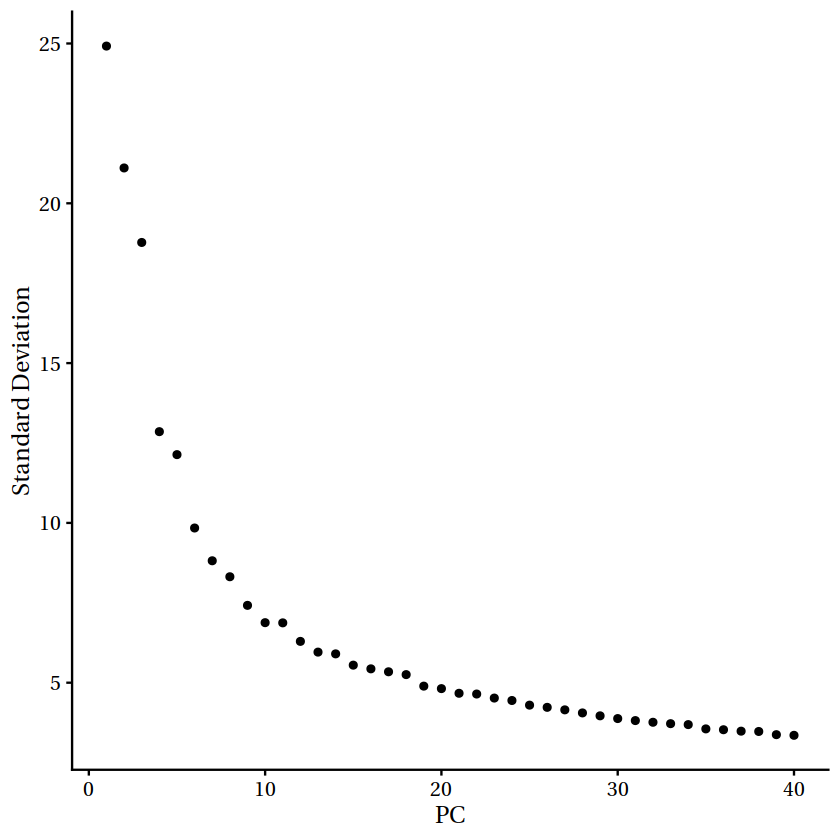

In [7]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

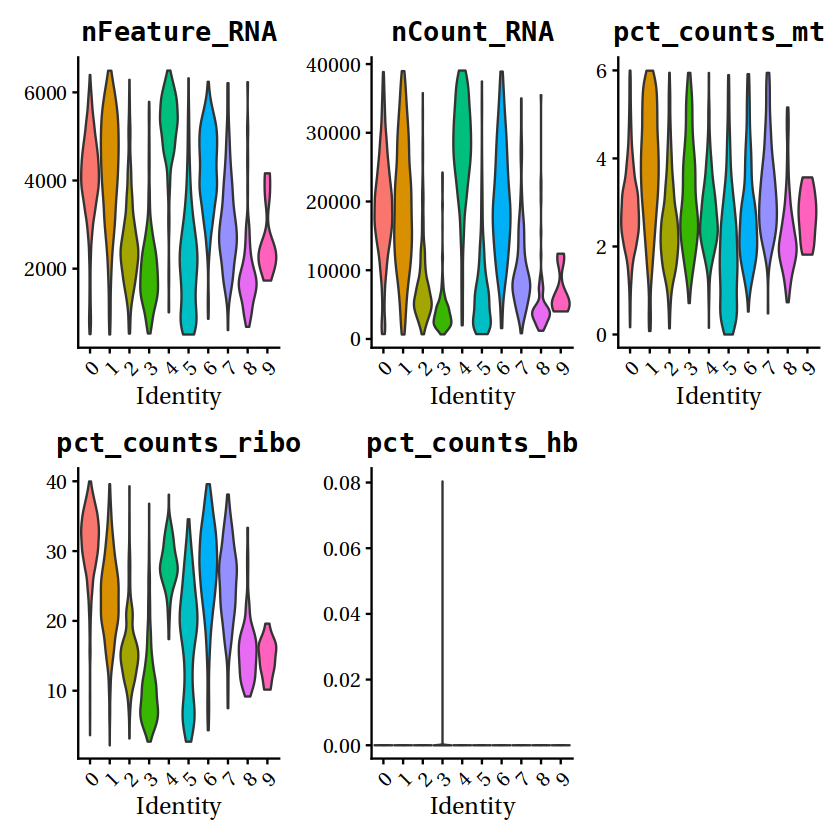

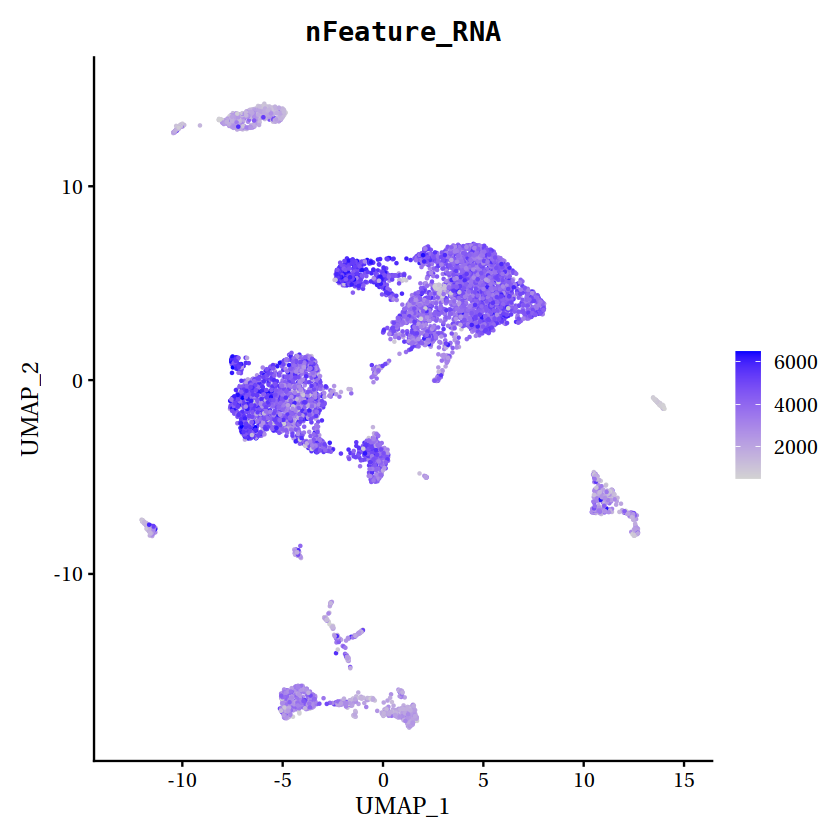

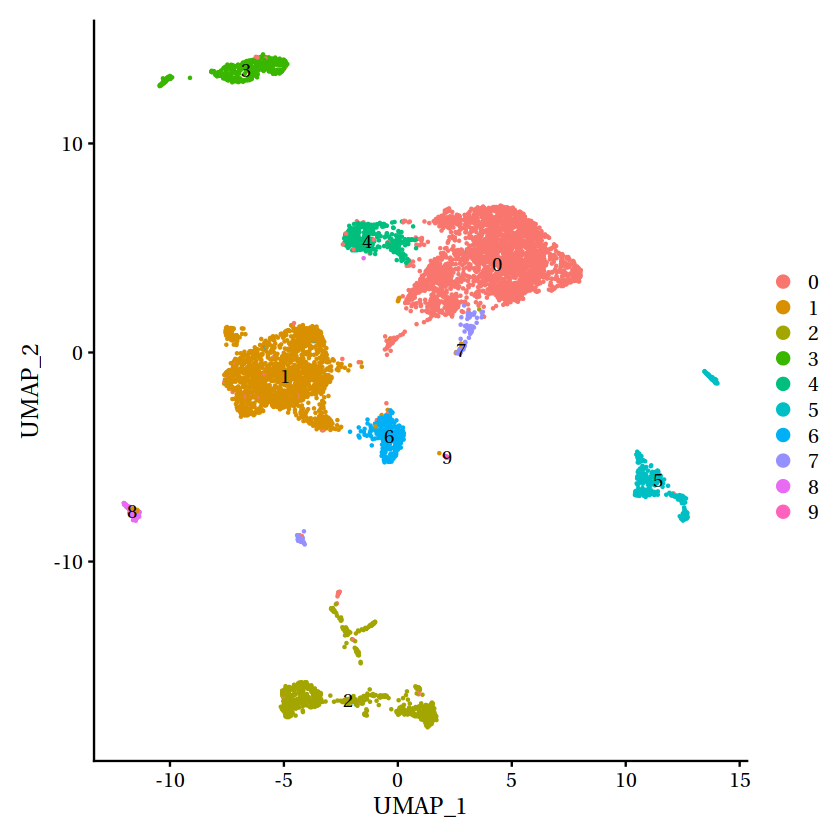

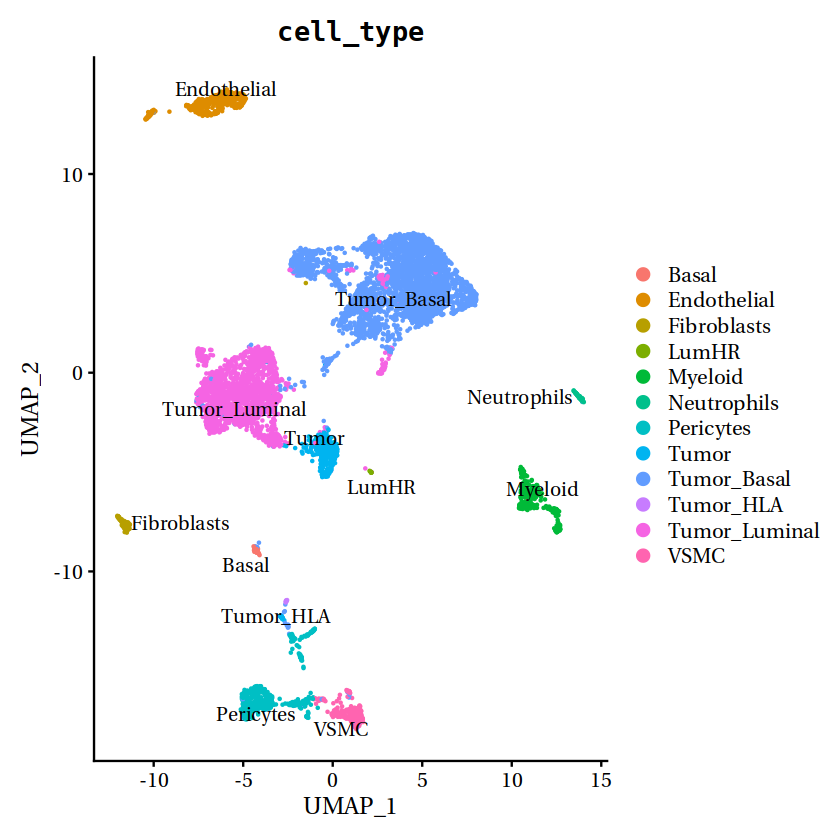

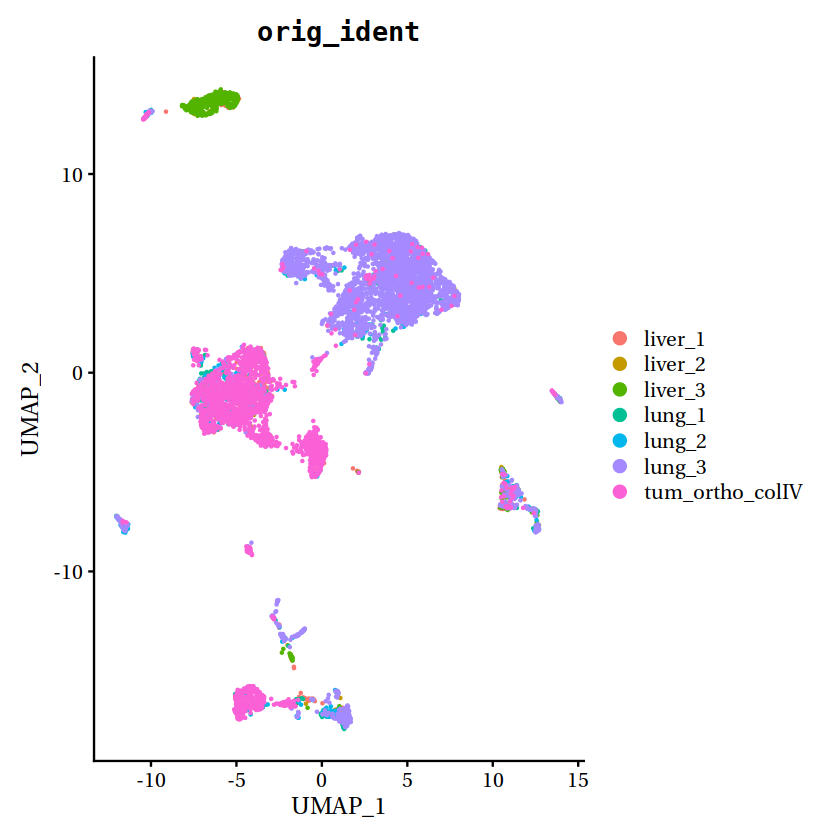

In [13]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

In [22]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA < 1000, WhichCells(obj, ident = 1), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 2000, WhichCells(obj, ident = c(0,6)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 3500, WhichCells(obj, ident = 4), invert = TRUE)

obj <- subset(obj, subset = nFeature_RNA > 3500, WhichCells(obj, ident = c(3,8)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4500, WhichCells(obj, ident = 2), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 5000, WhichCells(obj, ident = 5), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 5500, WhichCells(obj, ident = 7), invert = TRUE)

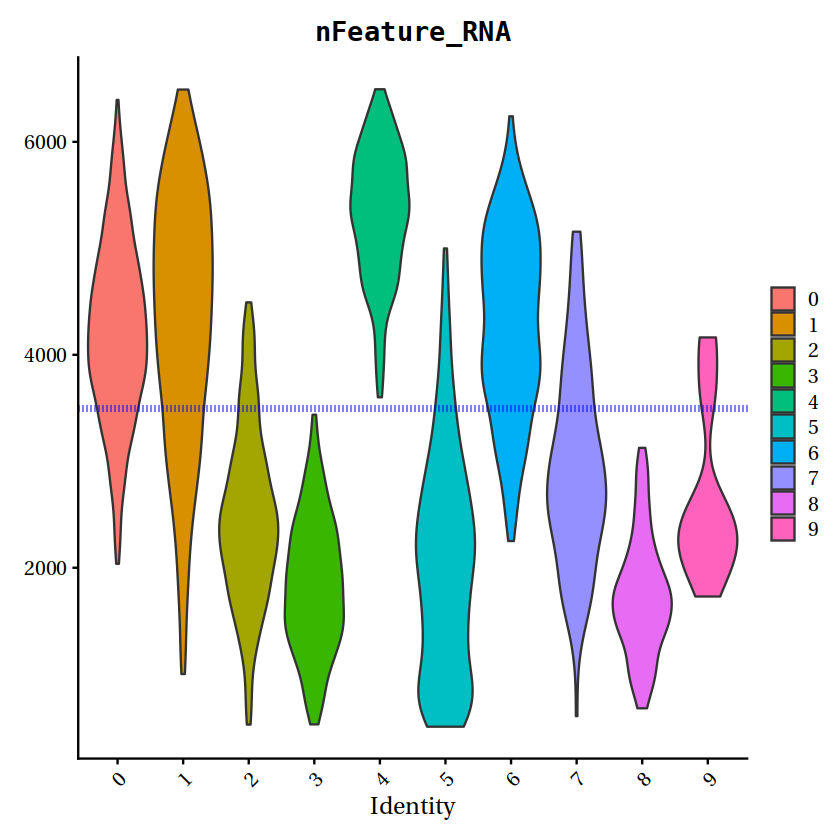

In [23]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 3500, linetype="dotted", 
                color = "blue", size=1.5)

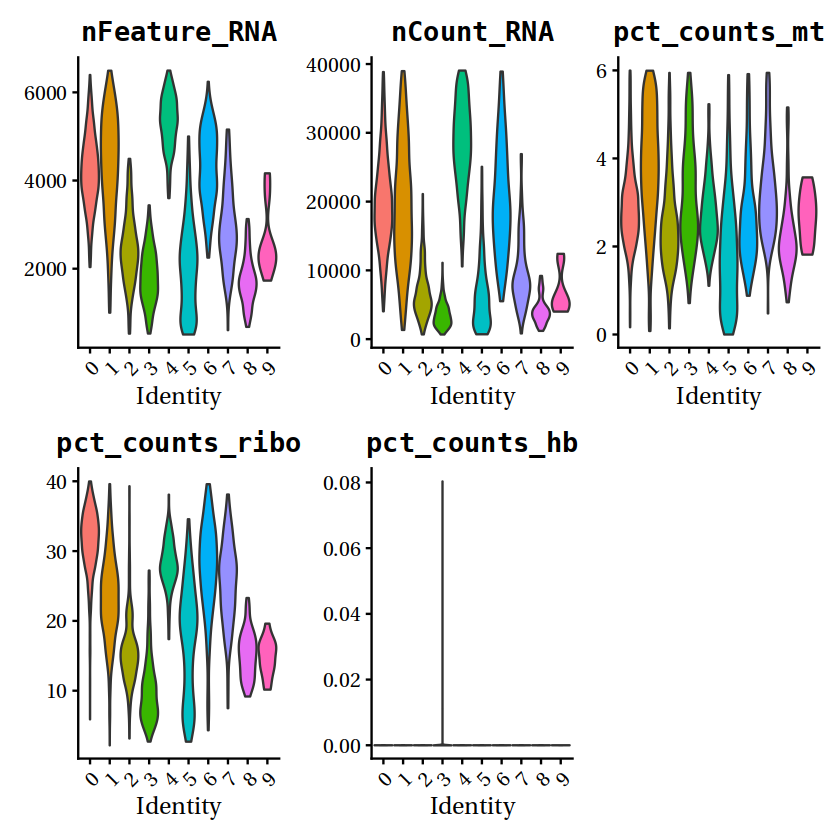

In [24]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

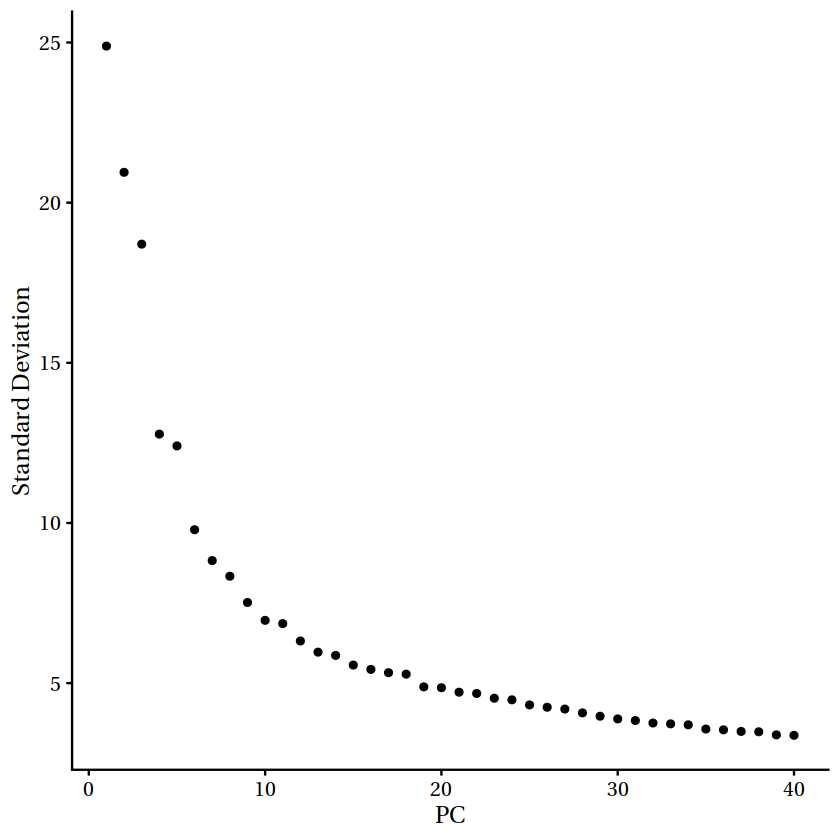

In [25]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

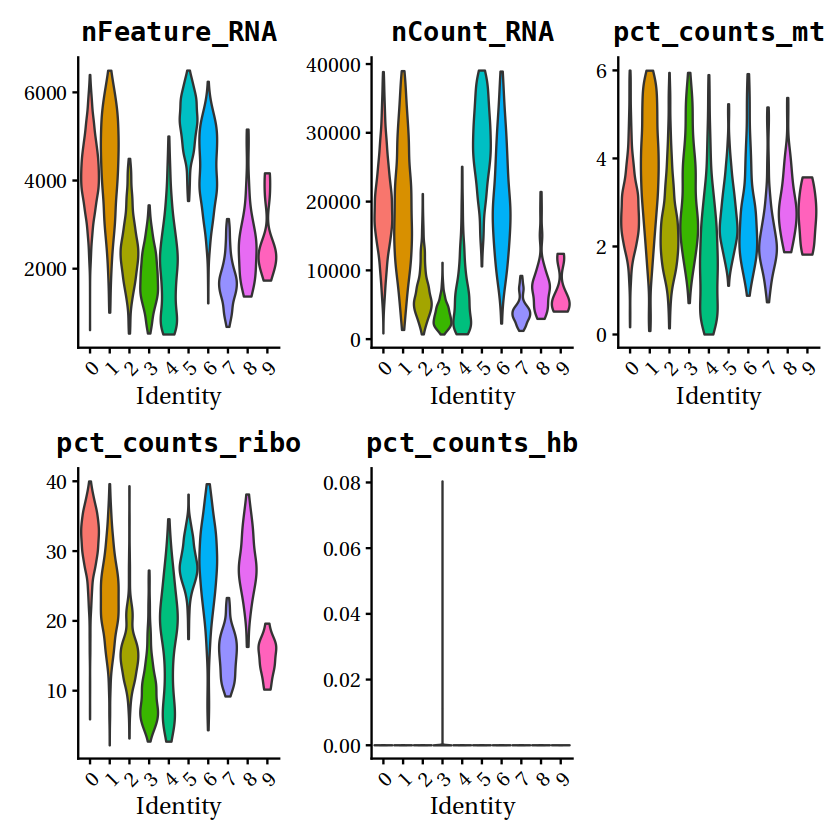

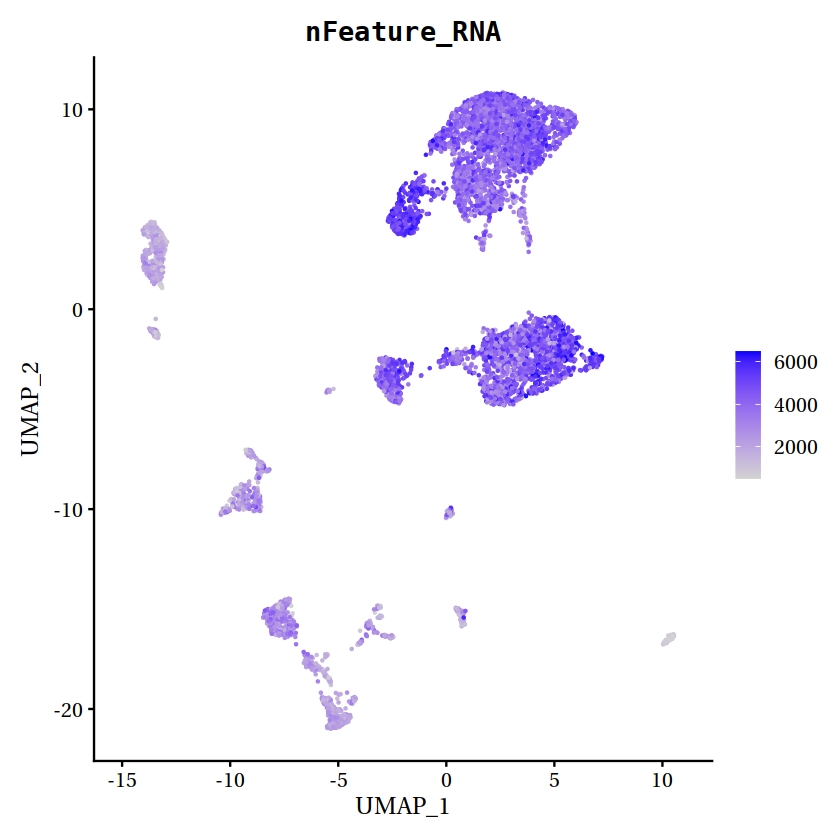

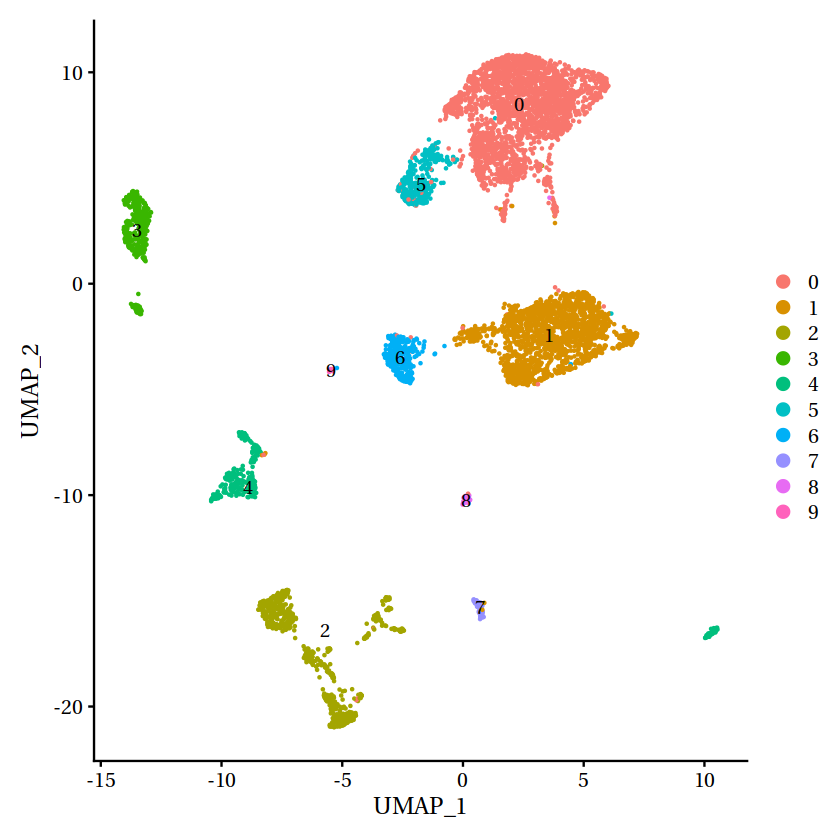

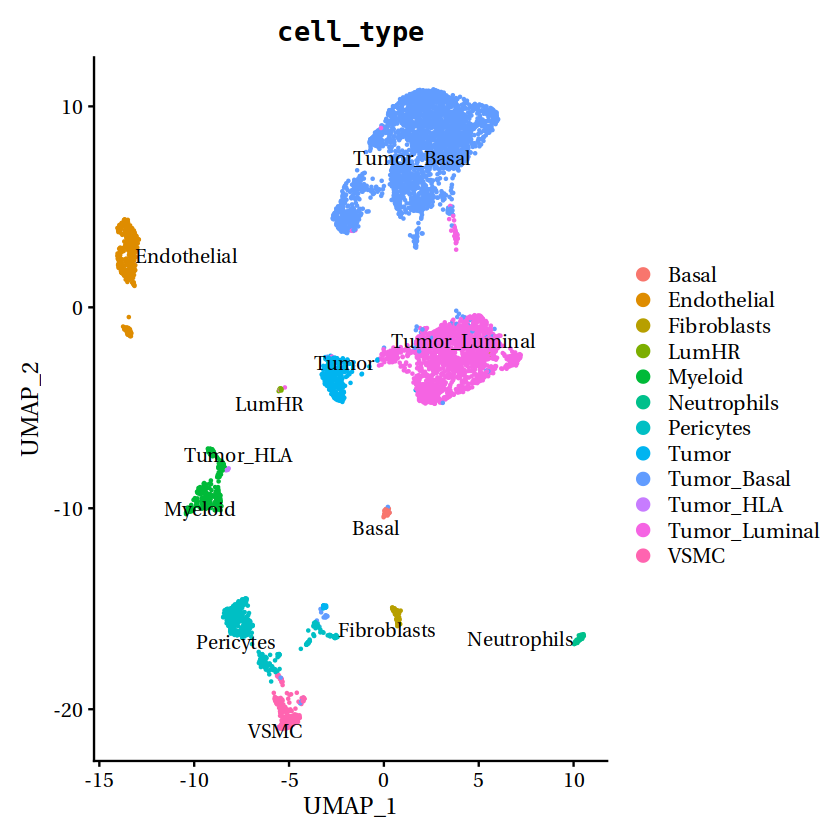

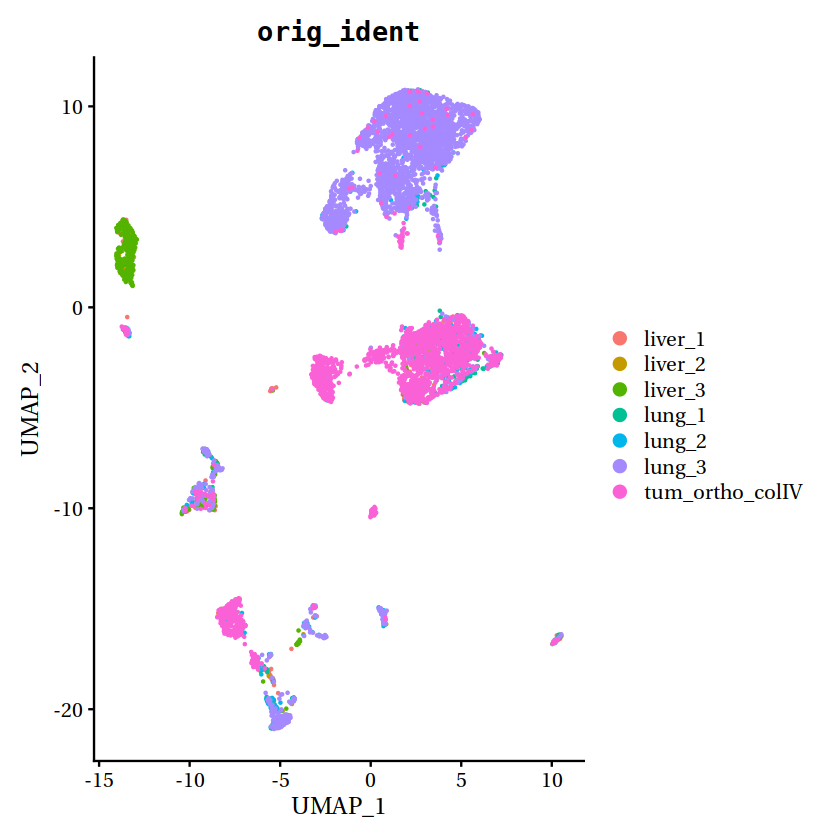

In [26]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

In [27]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA > 4000, WhichCells(obj, ident = 8), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 2000, WhichCells(obj, ident = c(0,6)), invert = TRUE)

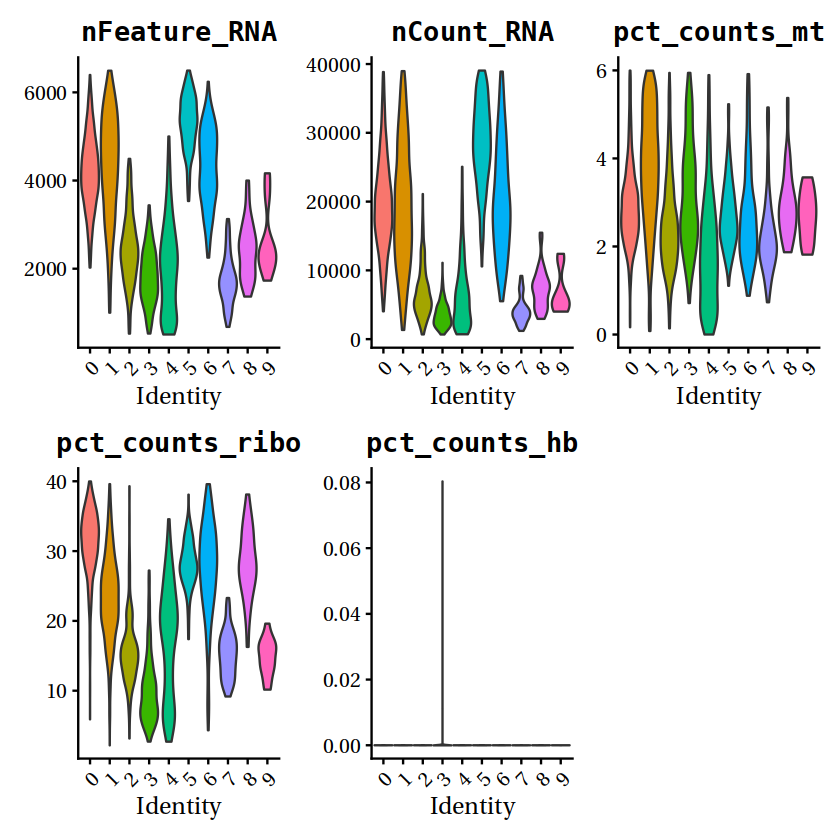

In [28]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

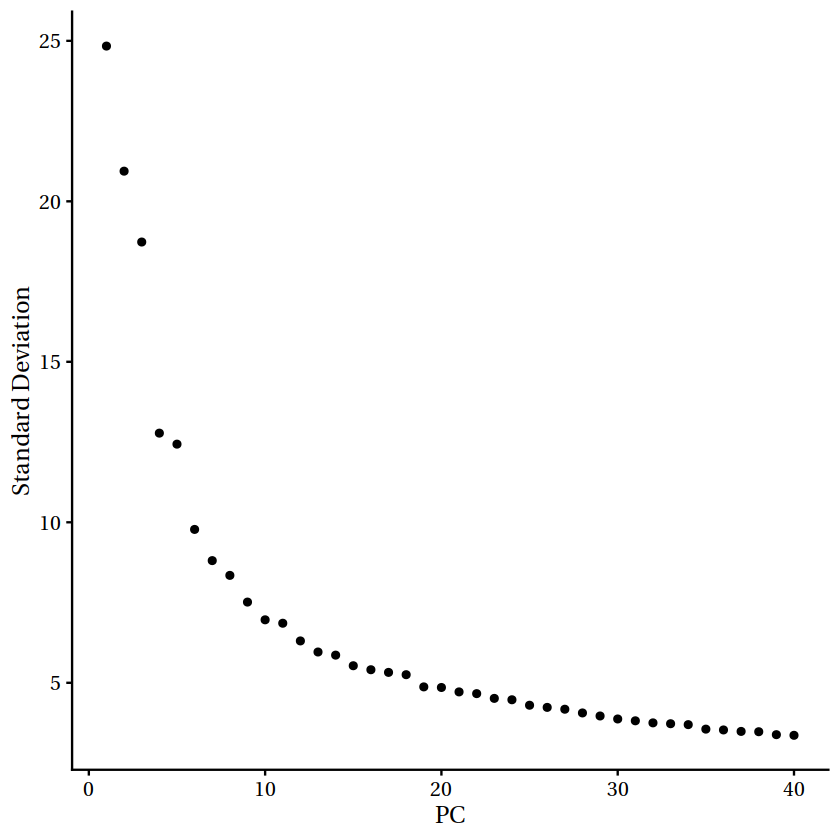

In [29]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

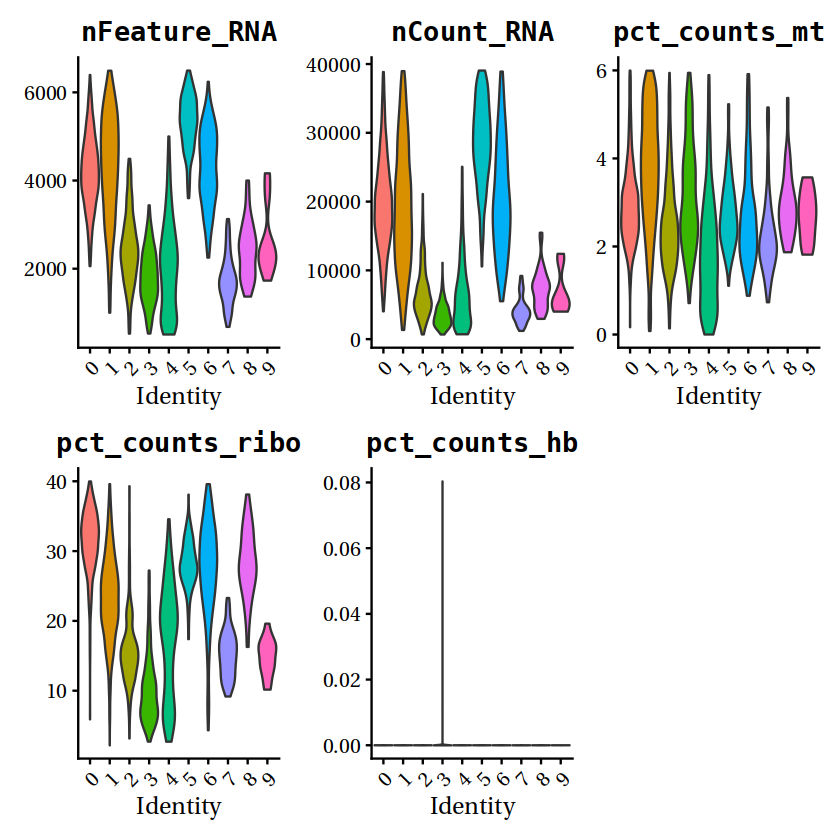

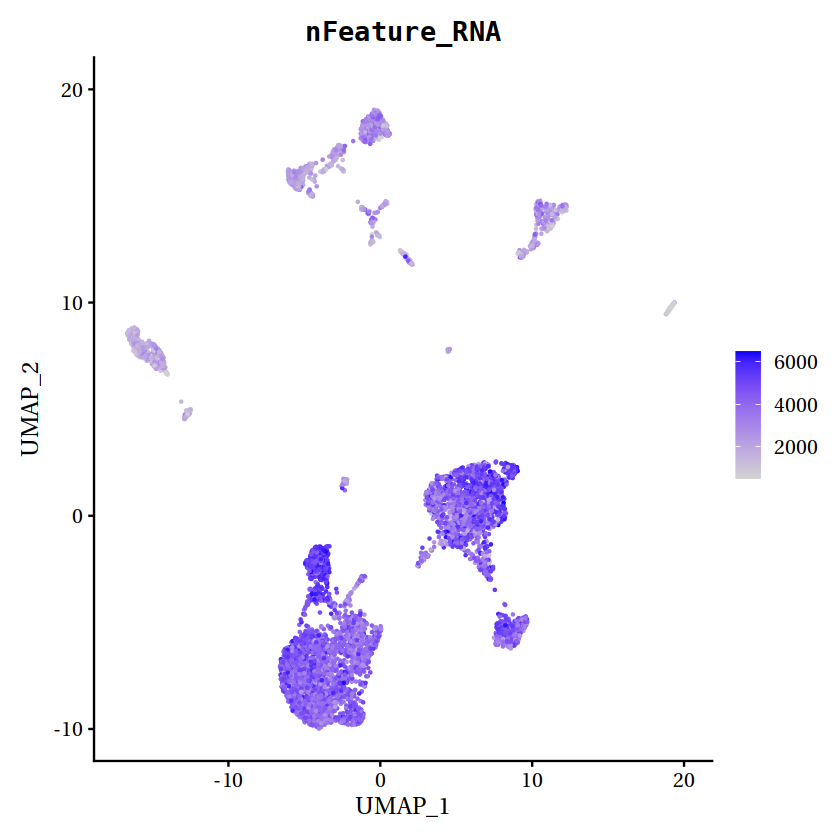

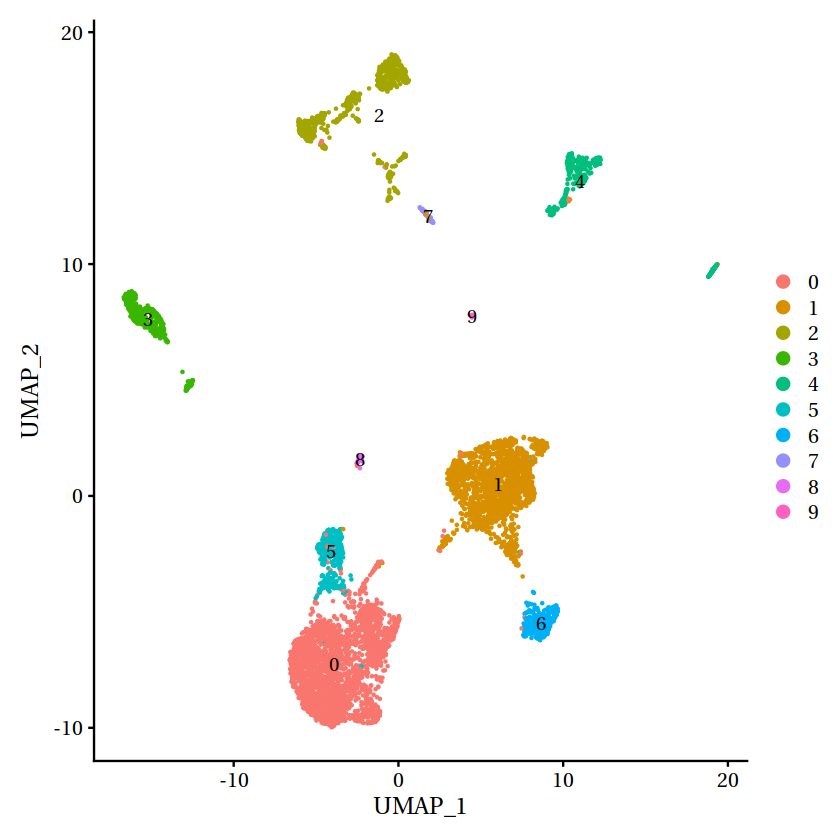

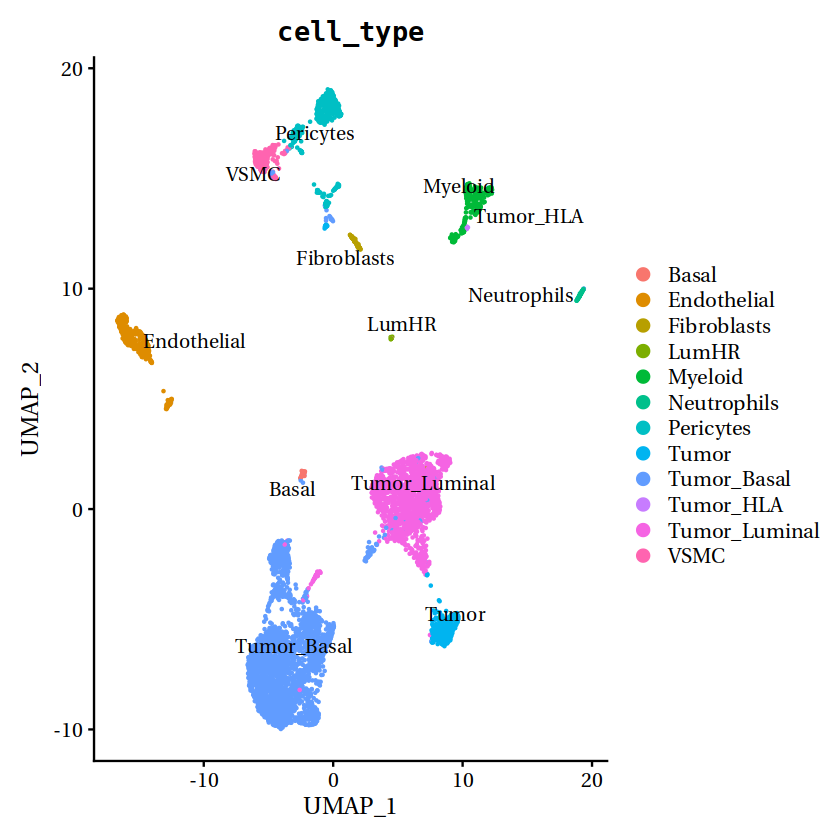

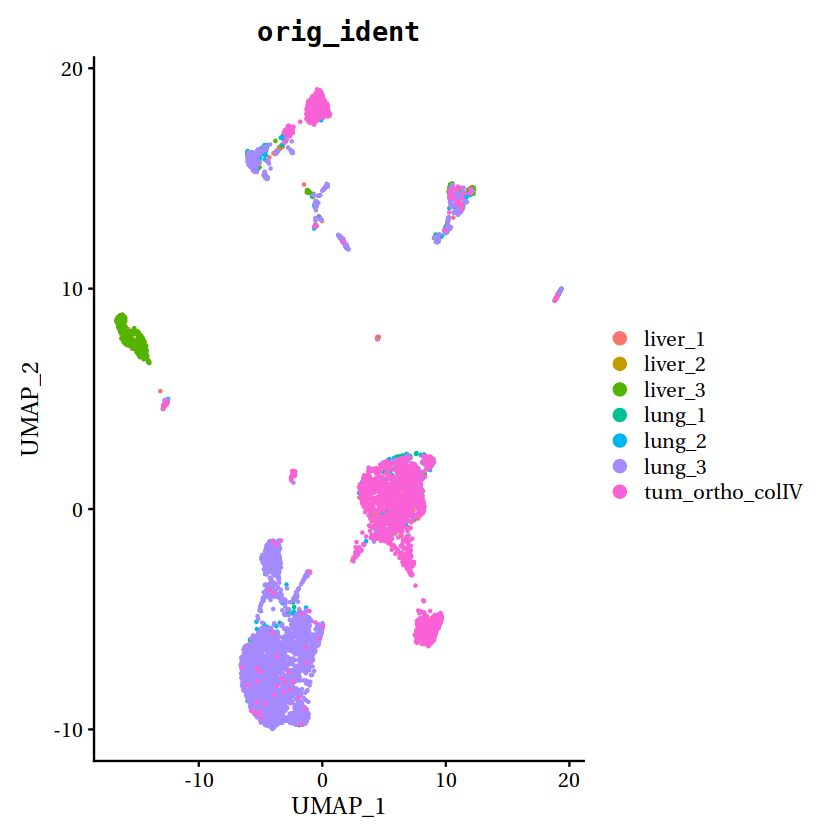

In [30]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

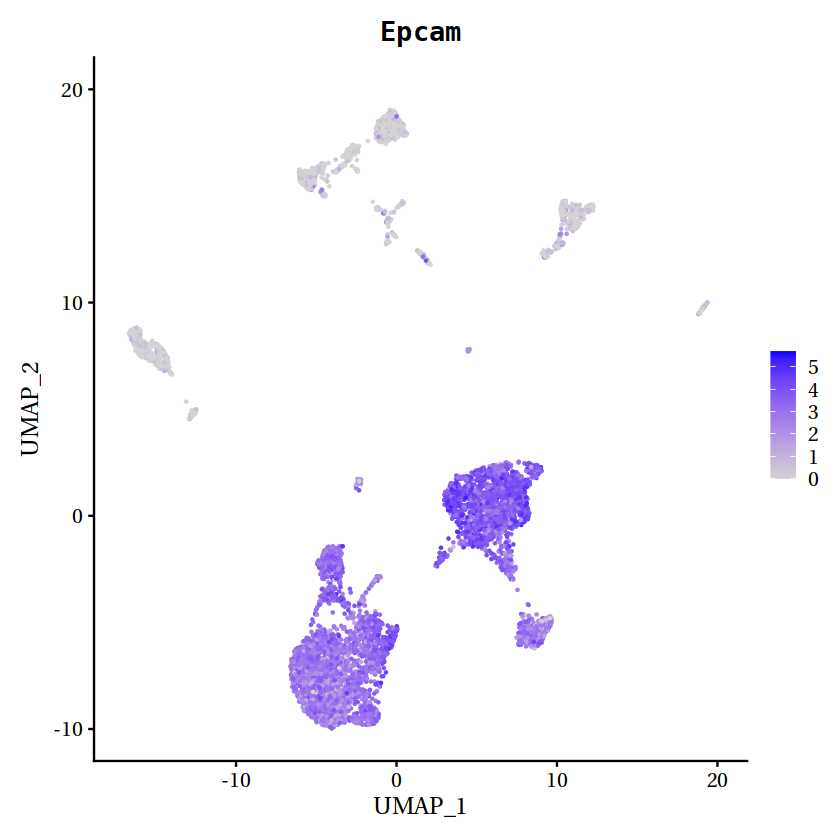

In [31]:
FeaturePlot(obj, "Epcam")

In [32]:
saveRDS(obj, "cellplex4_soupX.rds")

# after doublet prediction, CNV

In [34]:
obj <- readRDS("cellplex4_soupX_doubletfinder.rds")

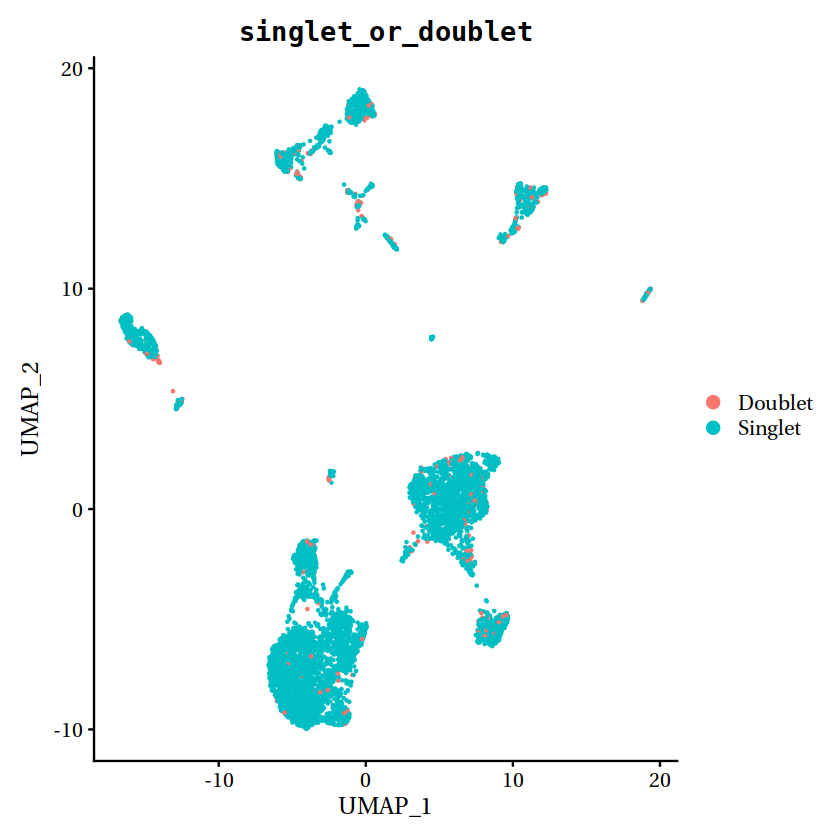

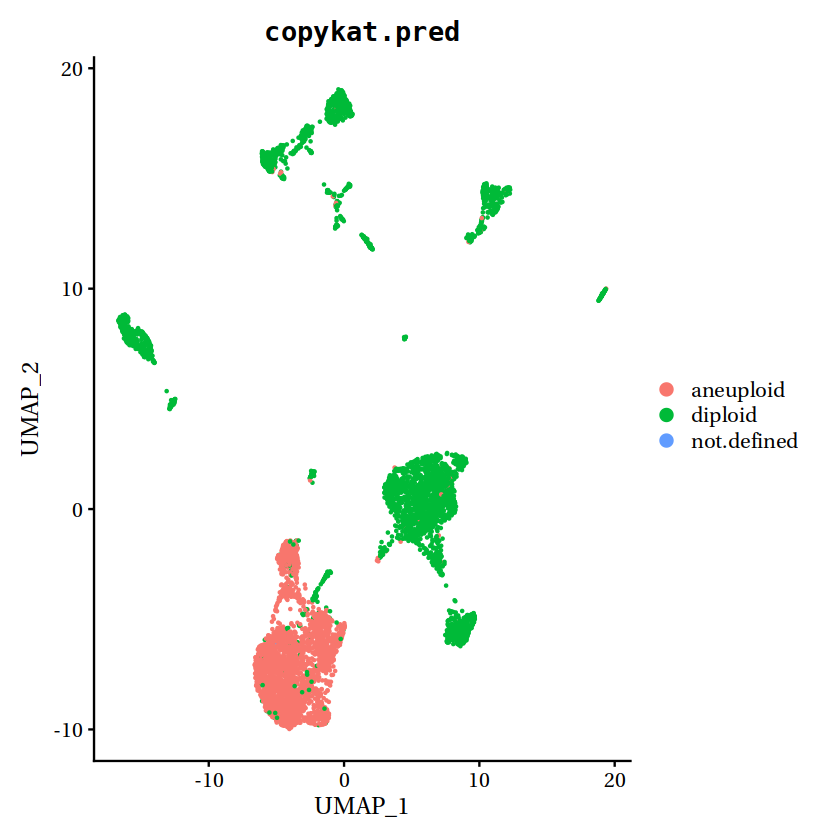

In [35]:
pred <- read.csv("cellplex_4_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

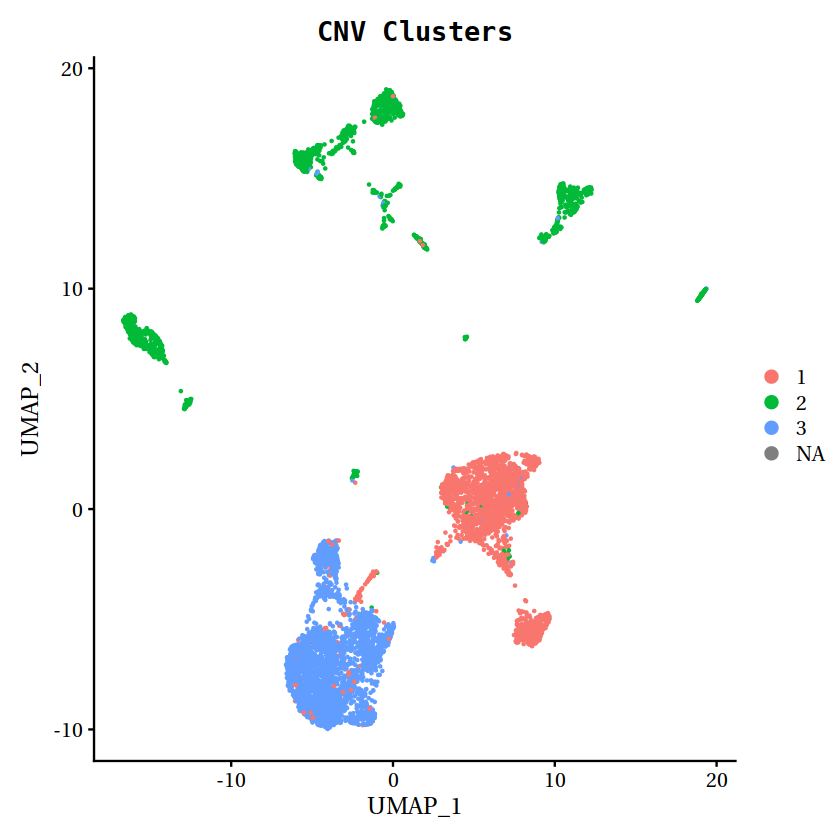

In [38]:
clust_res <- readRDS("cellplex_4_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 3, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

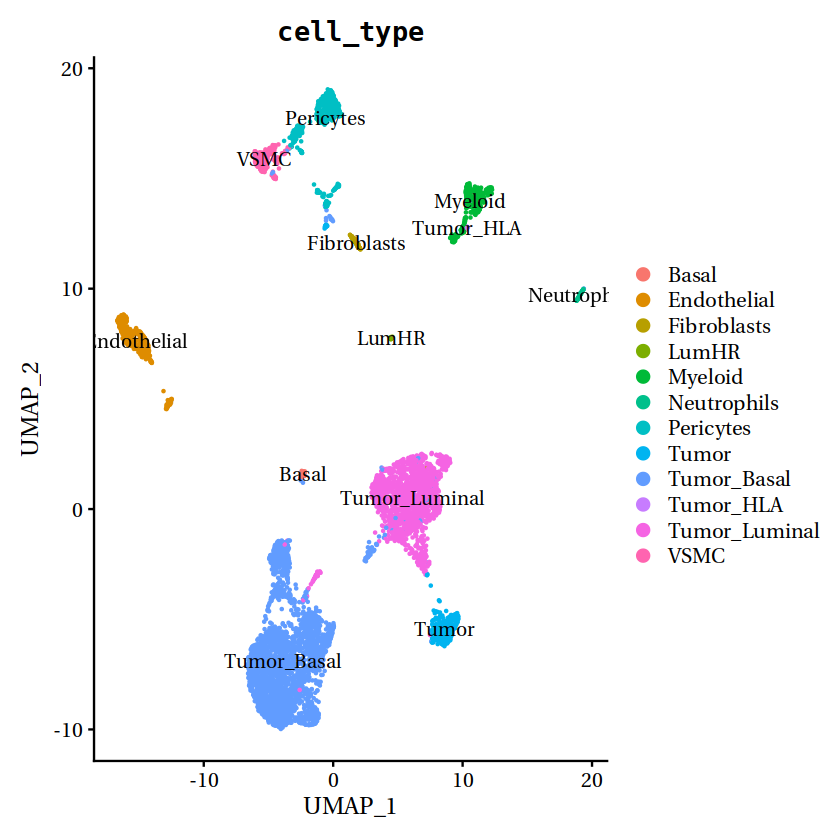

In [39]:
DimPlot(obj, group.by="cell_type", label = T)

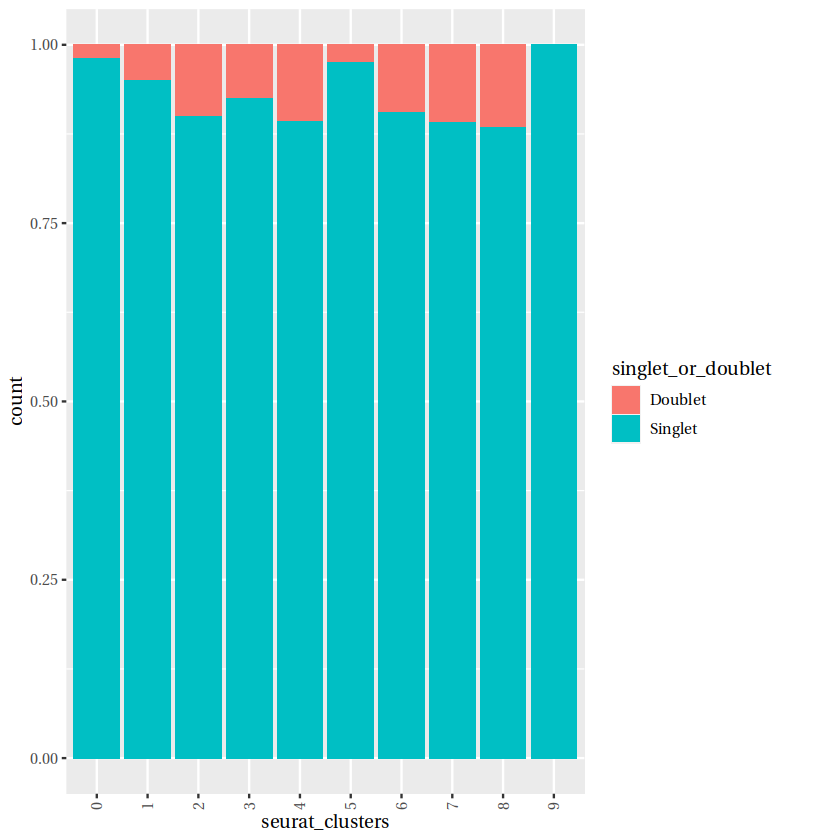

In [44]:
ggplot(obj@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

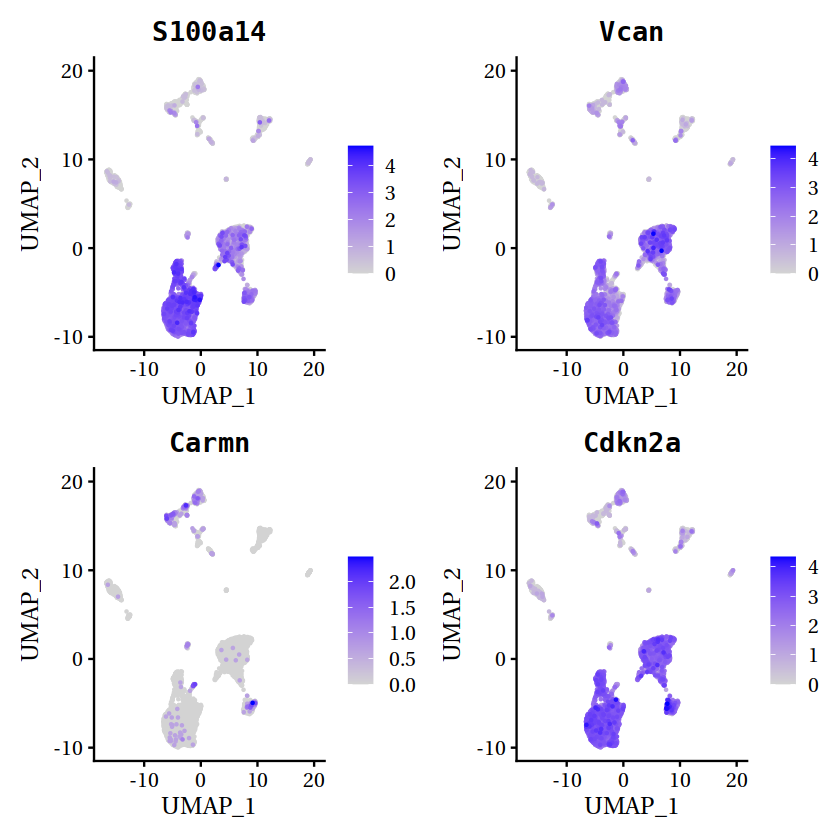

In [45]:
FeaturePlot(obj, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)

### check mets

In [70]:
table(obj$orig_ident)


        liver_1         liver_2         liver_3          lung_1          lung_2 
            334              64             444             209             393 
         lung_3 tum_ortho_colIV 
           3307            1956 

In [71]:
sub <- subset(obj, subset = orig_ident %in% c("tum_ortho_colIV"), invert = T)

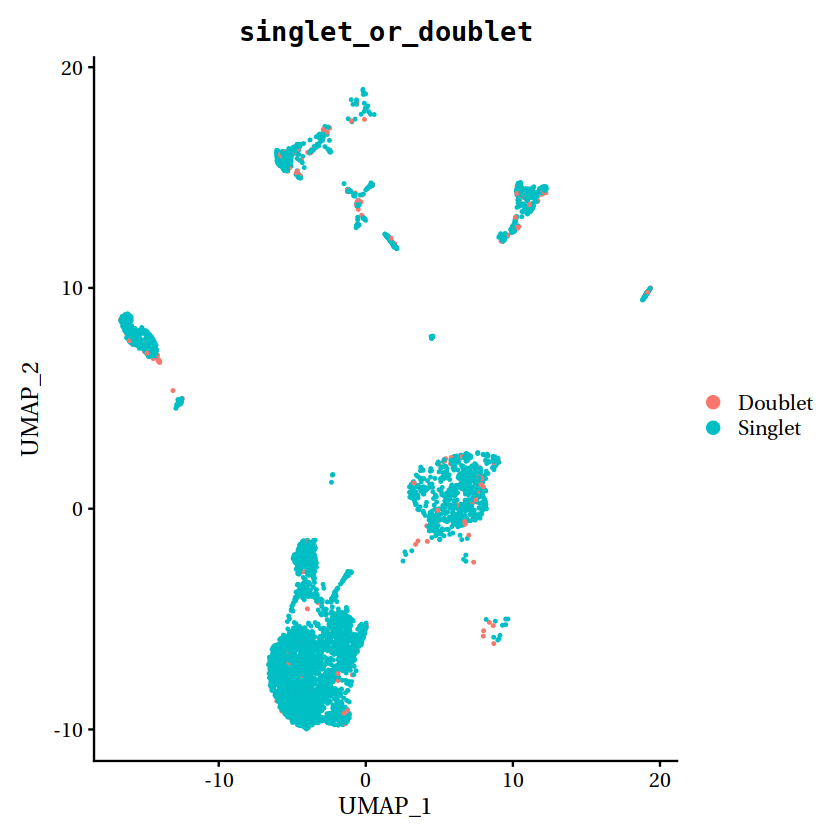

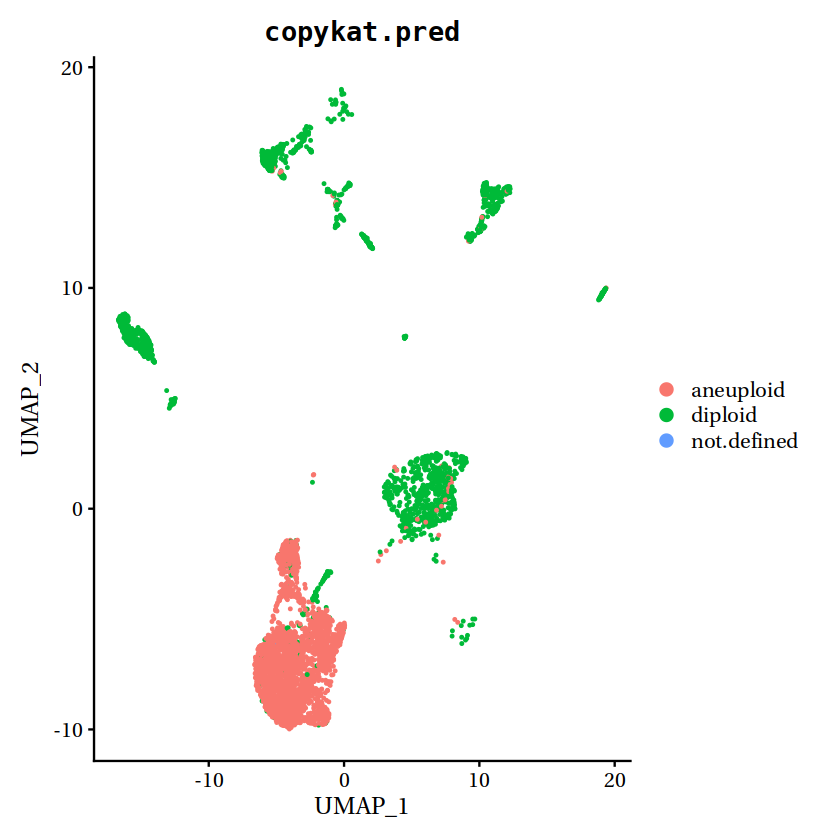

In [72]:
DimPlot(sub, group.by = "singlet_or_doublet")
DimPlot(sub, group.by="copykat.pred")

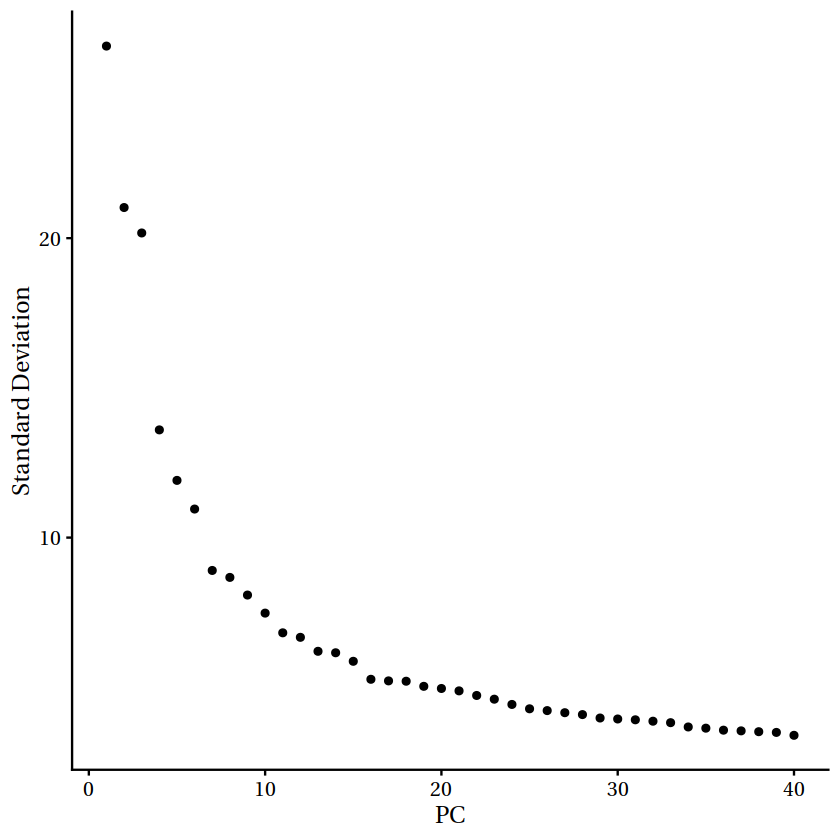

In [73]:
sub <- SCTransform(sub, variable.features.n = 1500, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

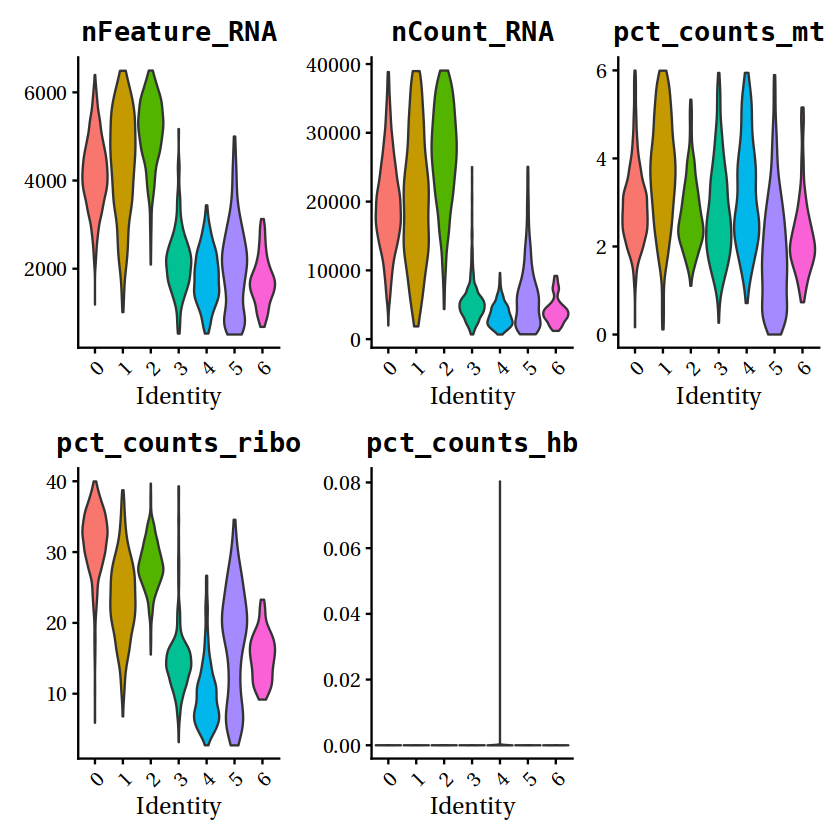

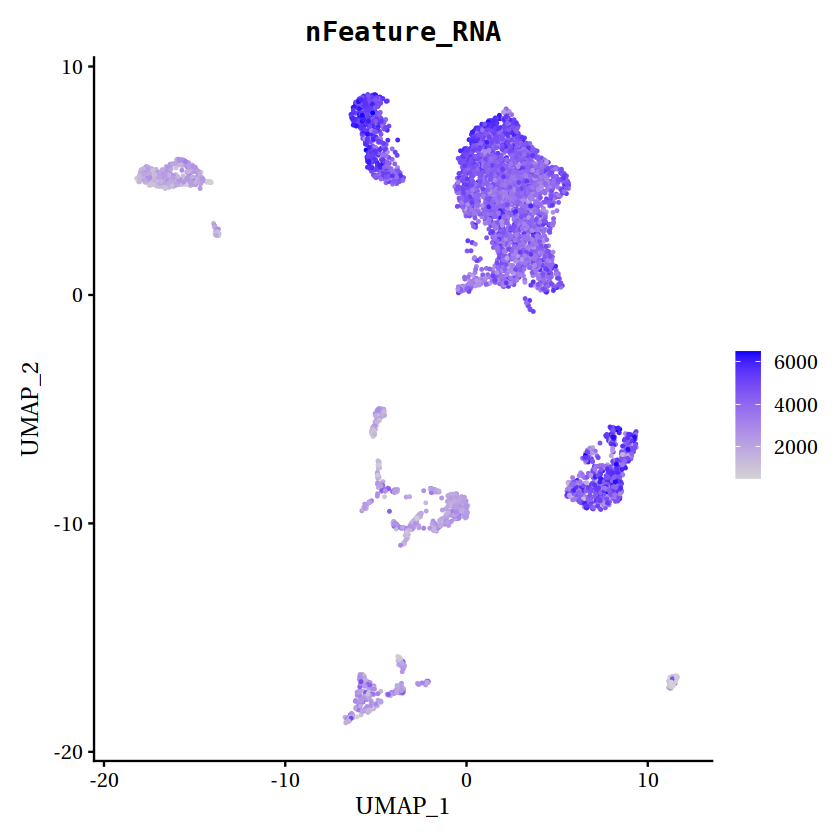

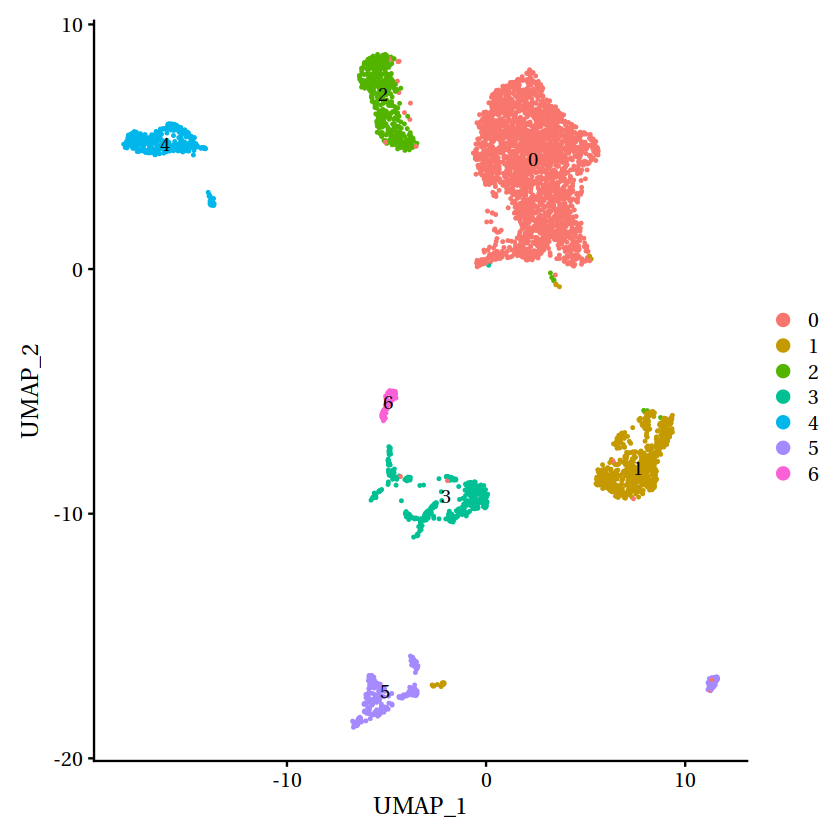

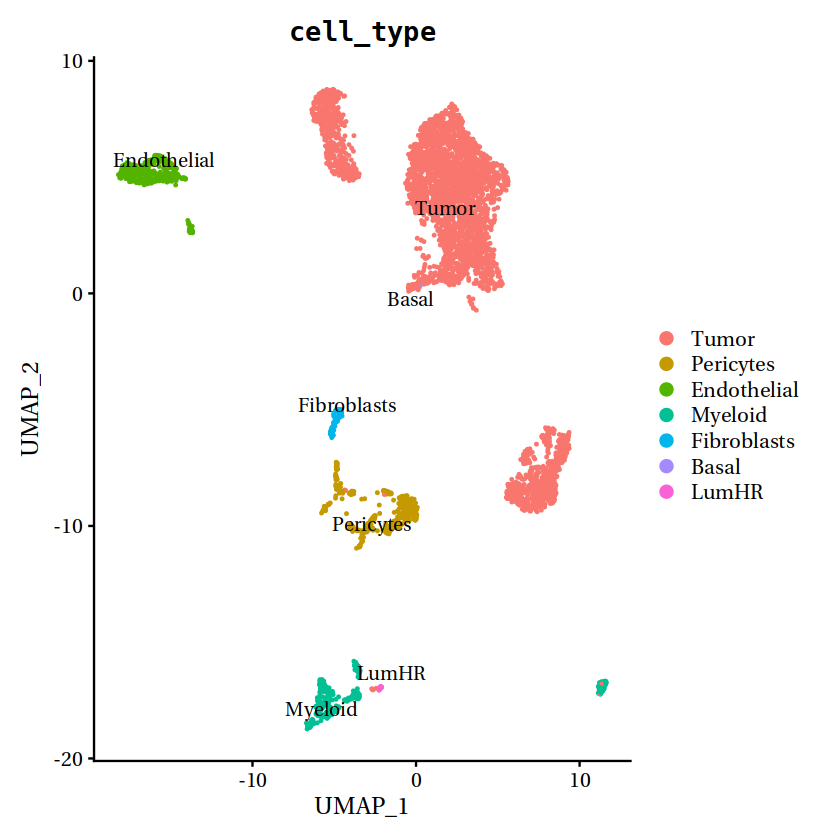

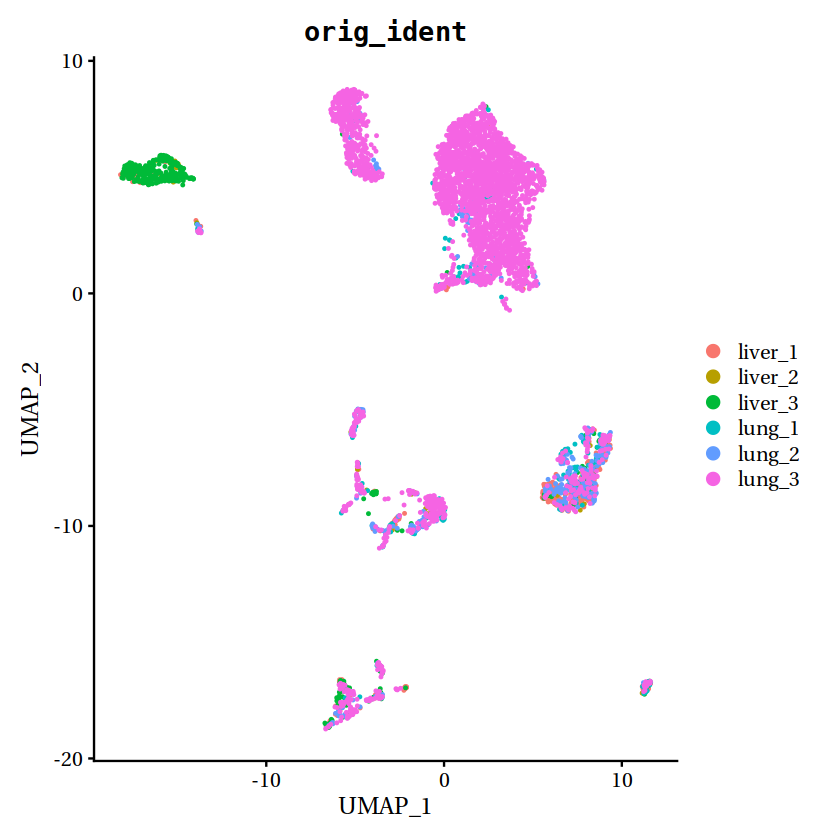

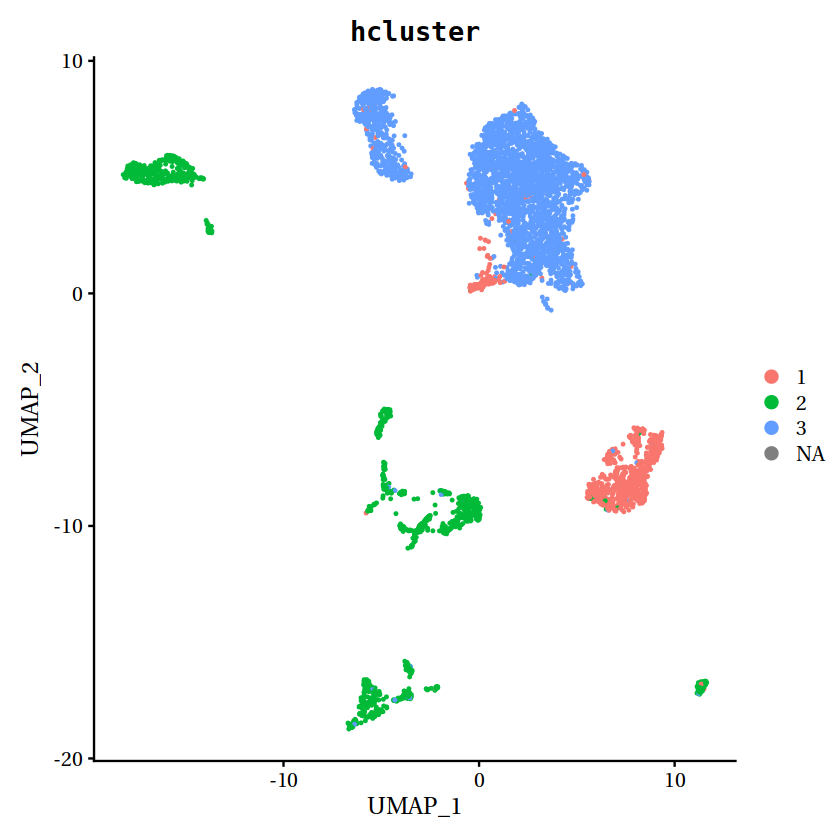

In [74]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:30, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:30, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "hcluster", label = F)

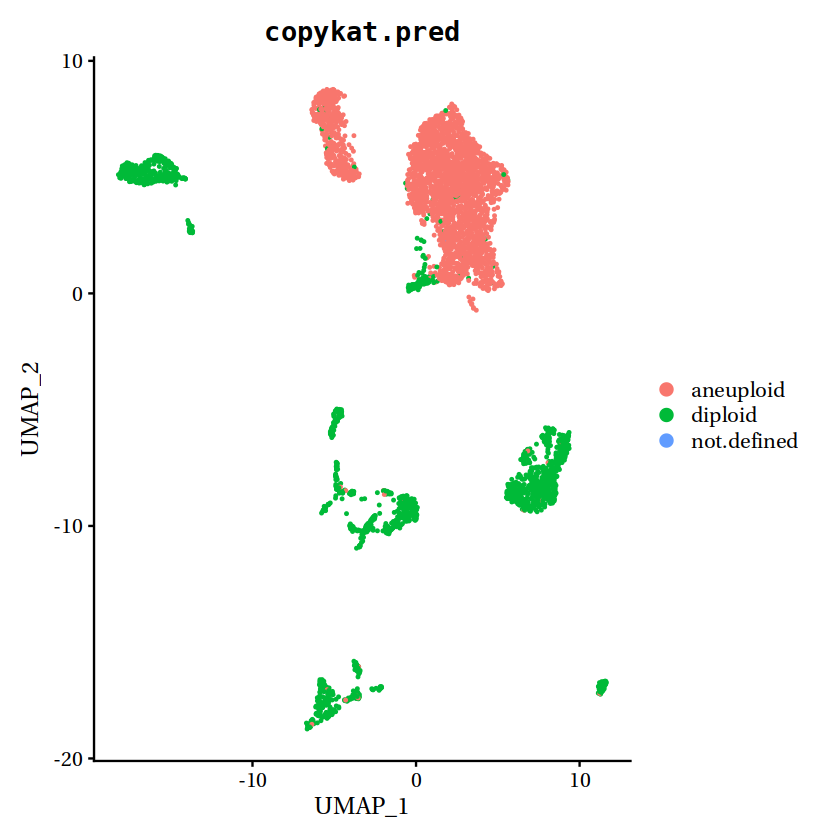

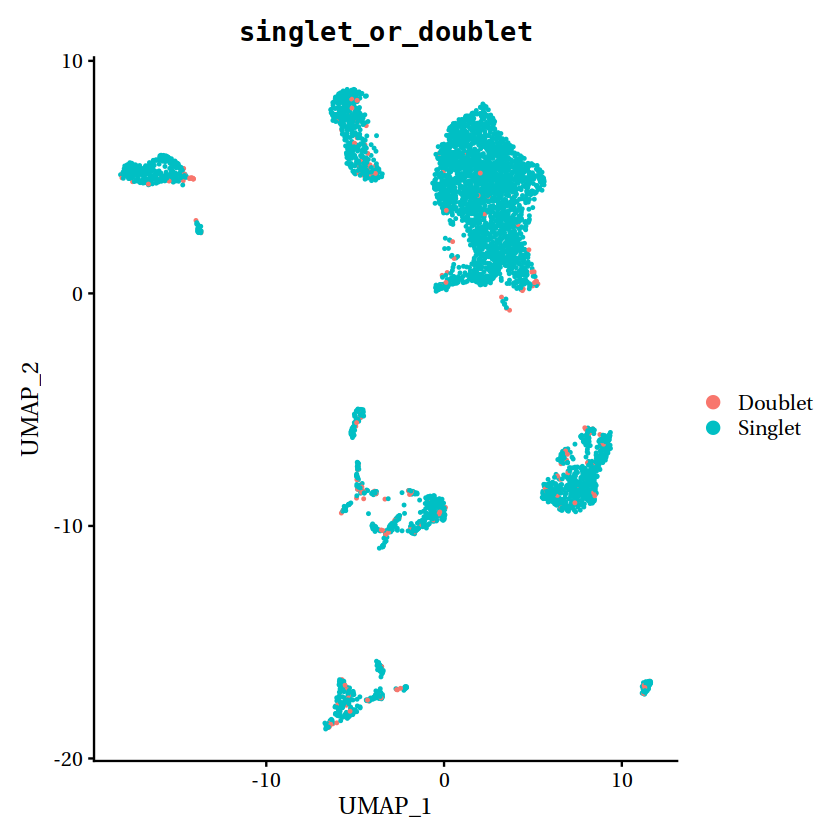

In [75]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")

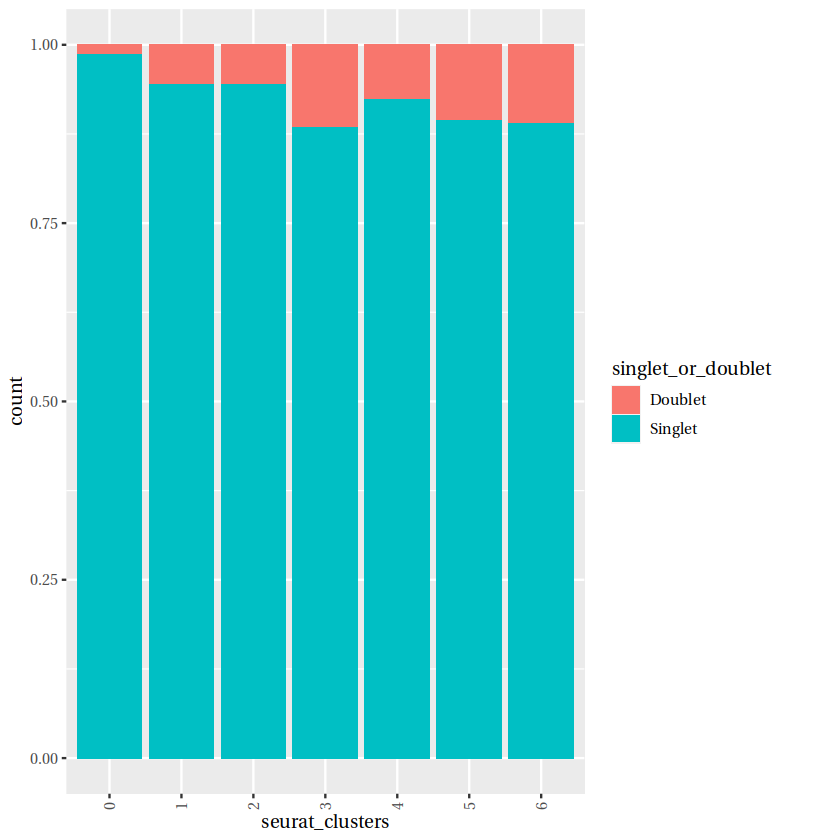

In [76]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

Idents(sub) <- "cell_type"
DimPlot(sub, cells.highlight = WhichCells(sub, ident = c("Tumor")))+ggtitle("Tumor") #none

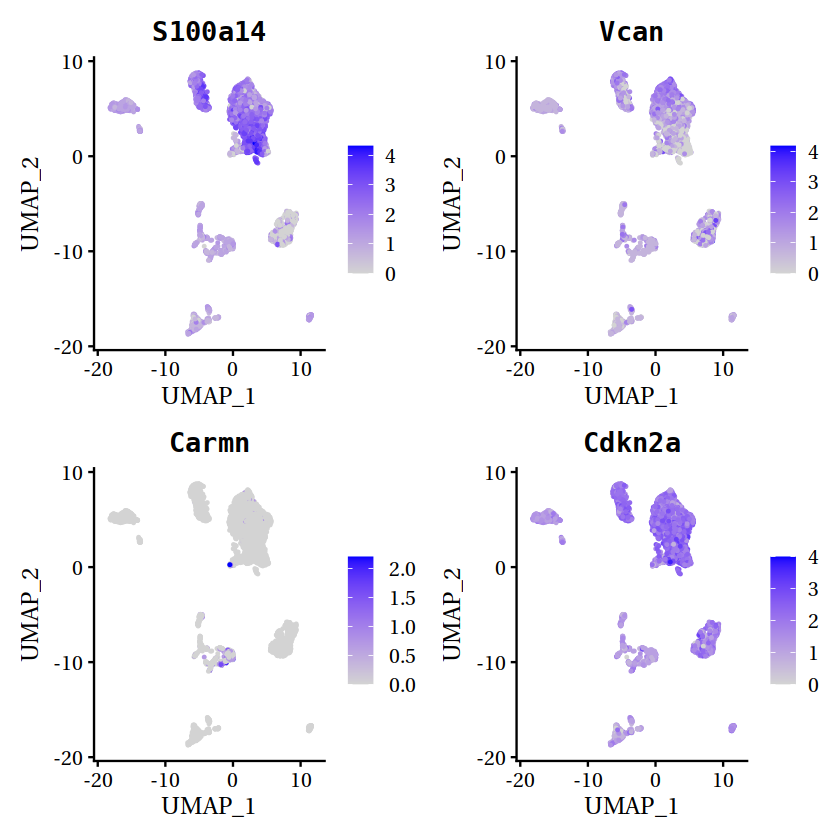

In [79]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"))

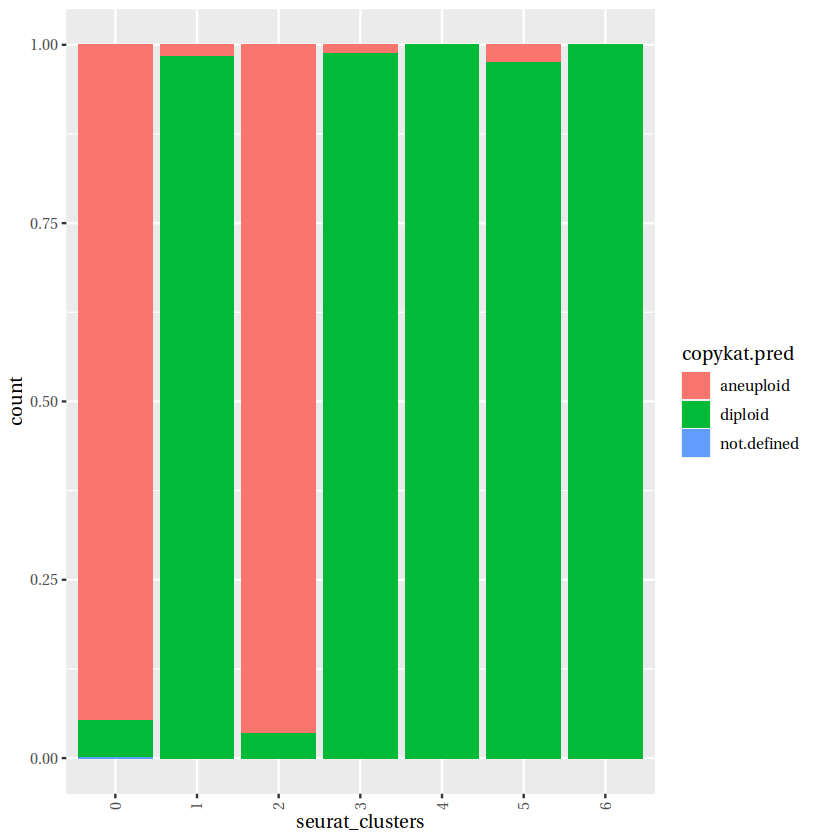

In [80]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check but don't save ortho tumor

In [81]:
sub <- subset(obj, subset = orig_ident %in% c("tum_ortho_colIV"))

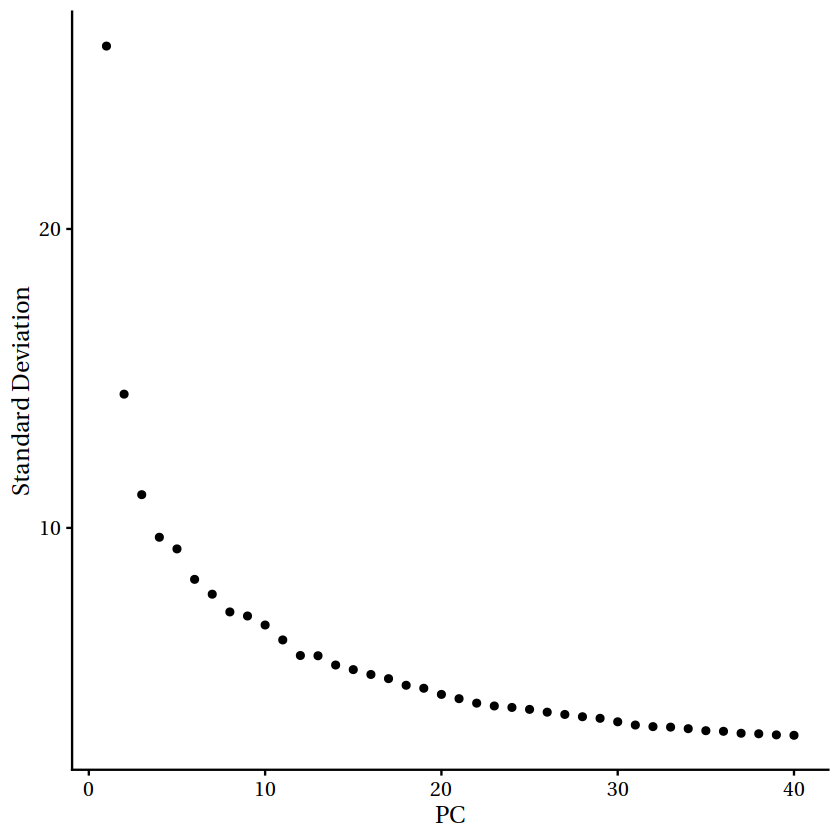

In [82]:
sub <- SCTransform(sub, variable.features.n = 1500, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


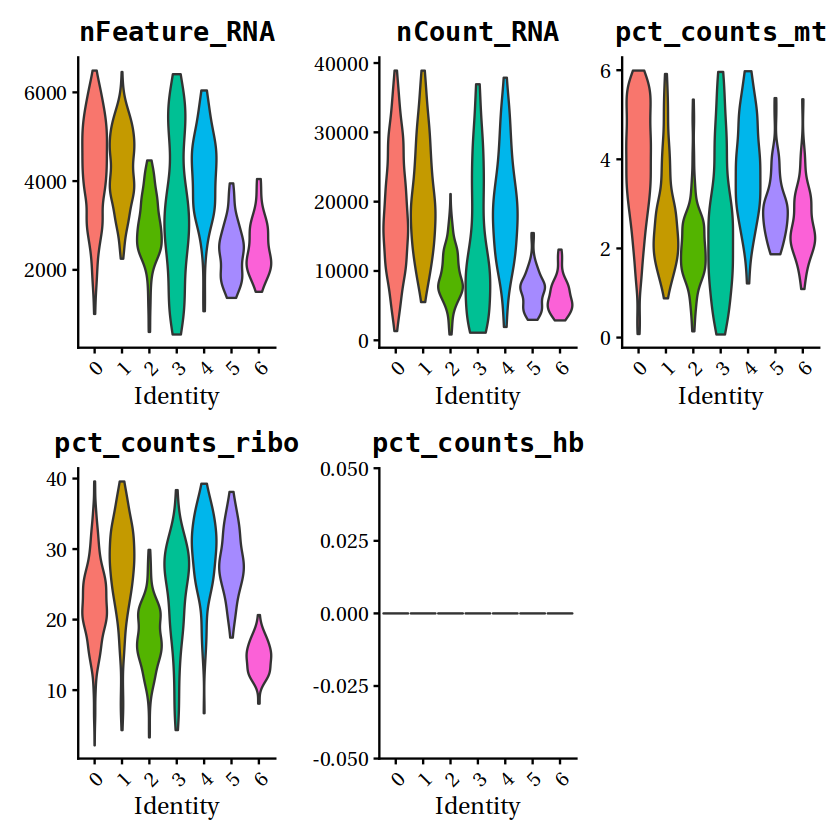

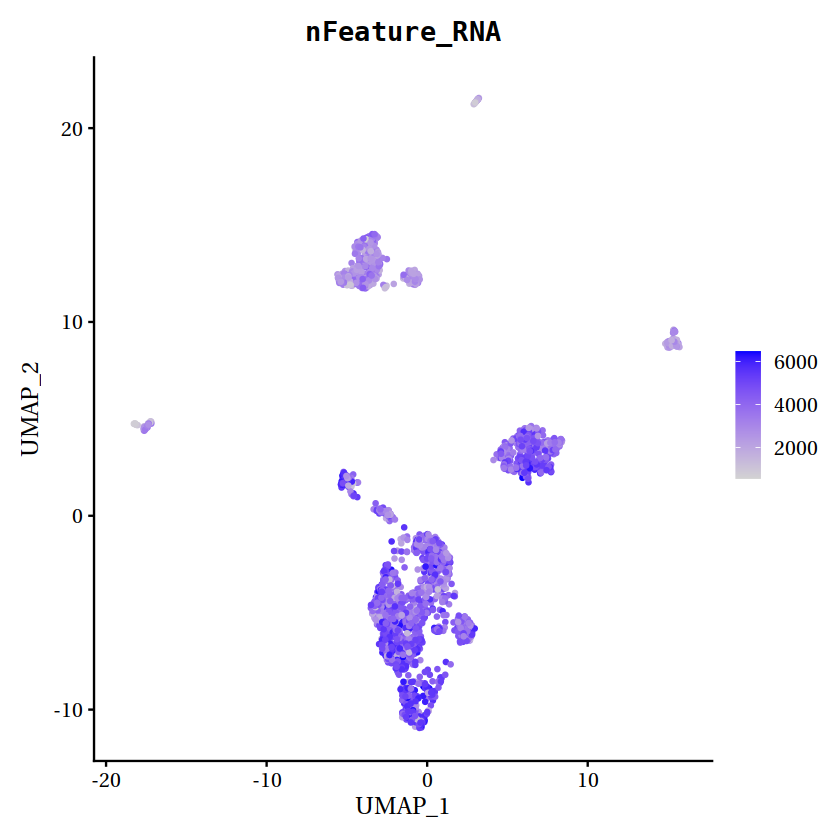

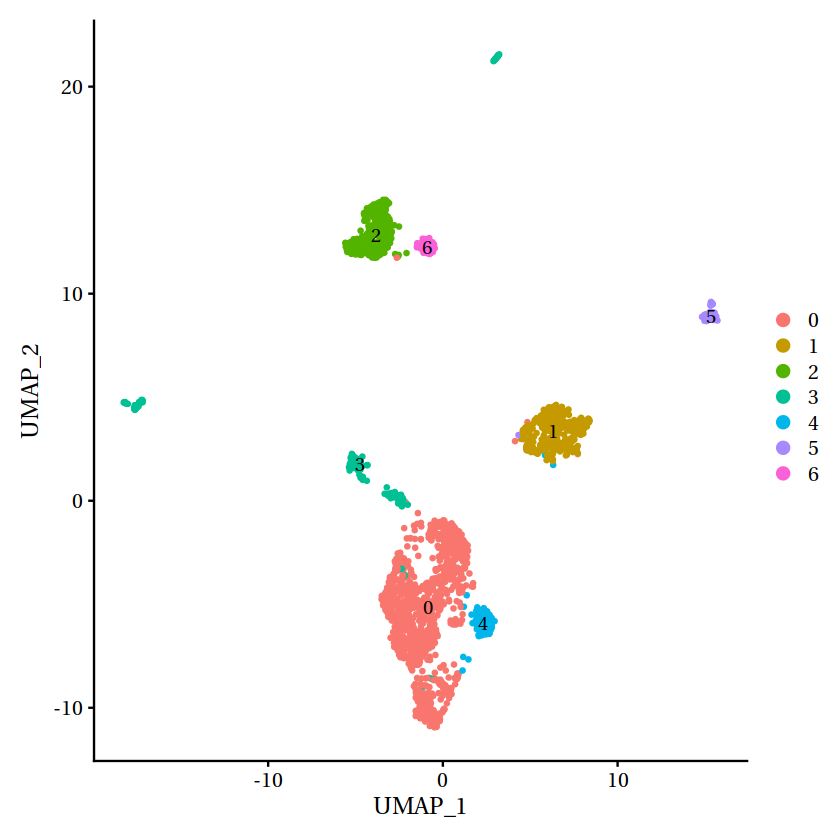

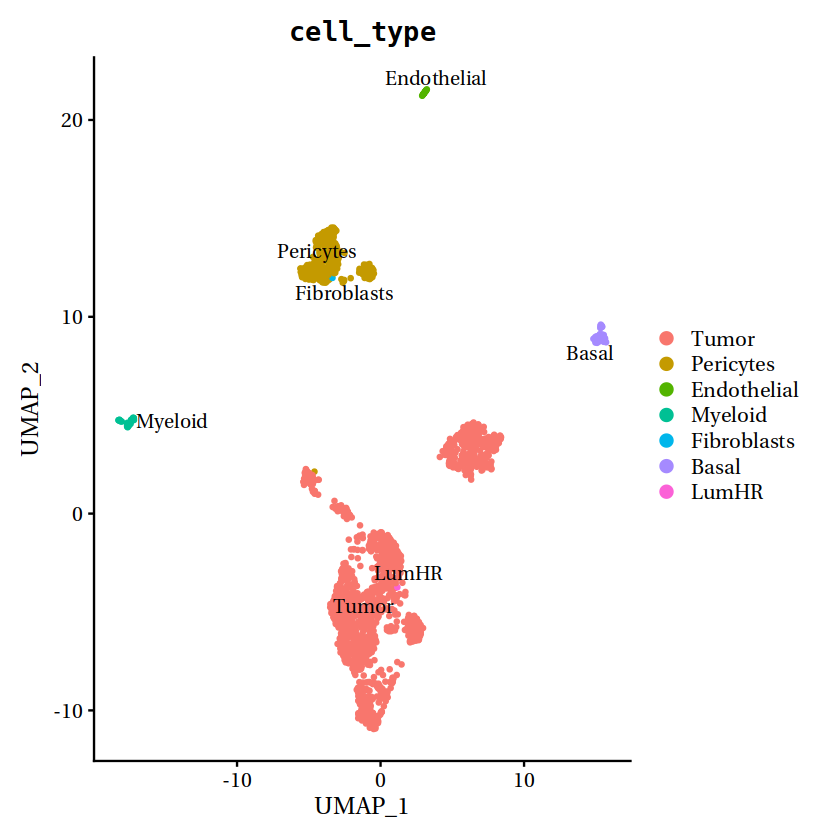

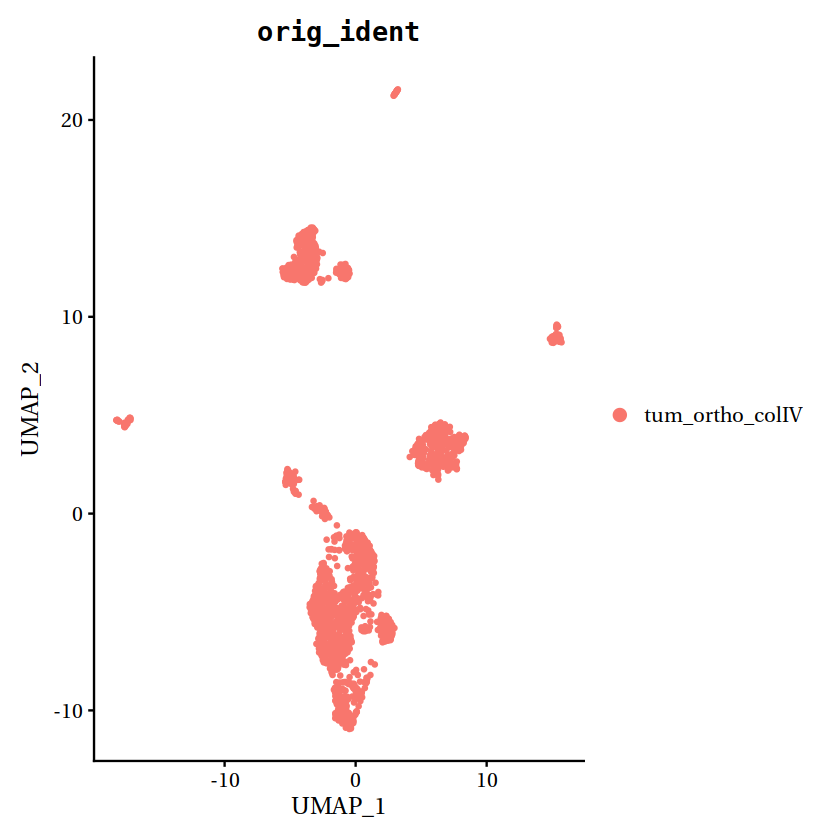

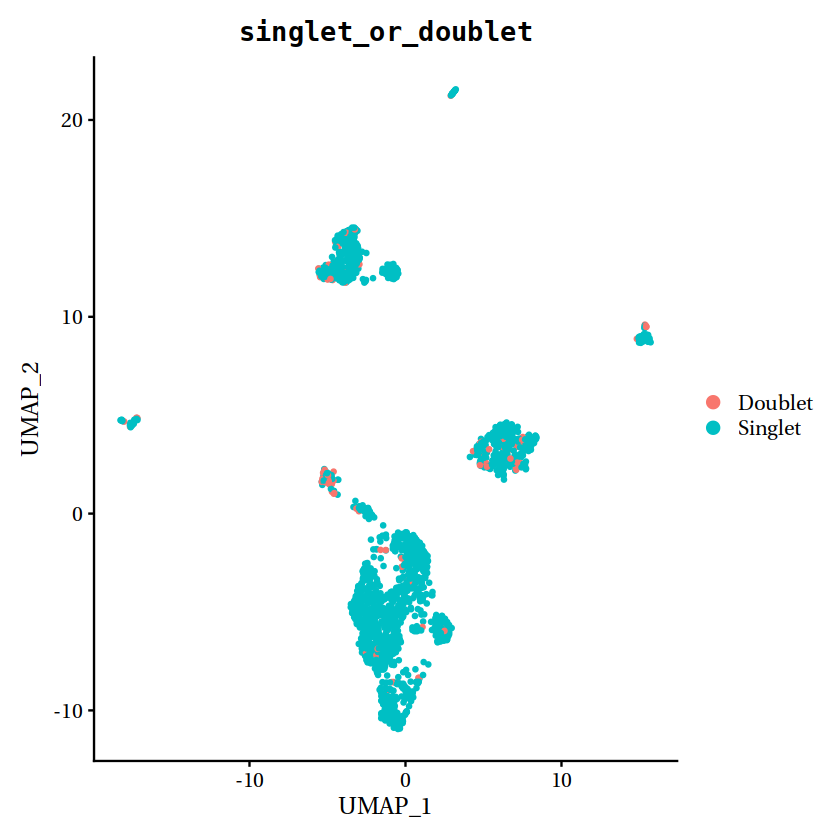

In [83]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:30, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:30, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

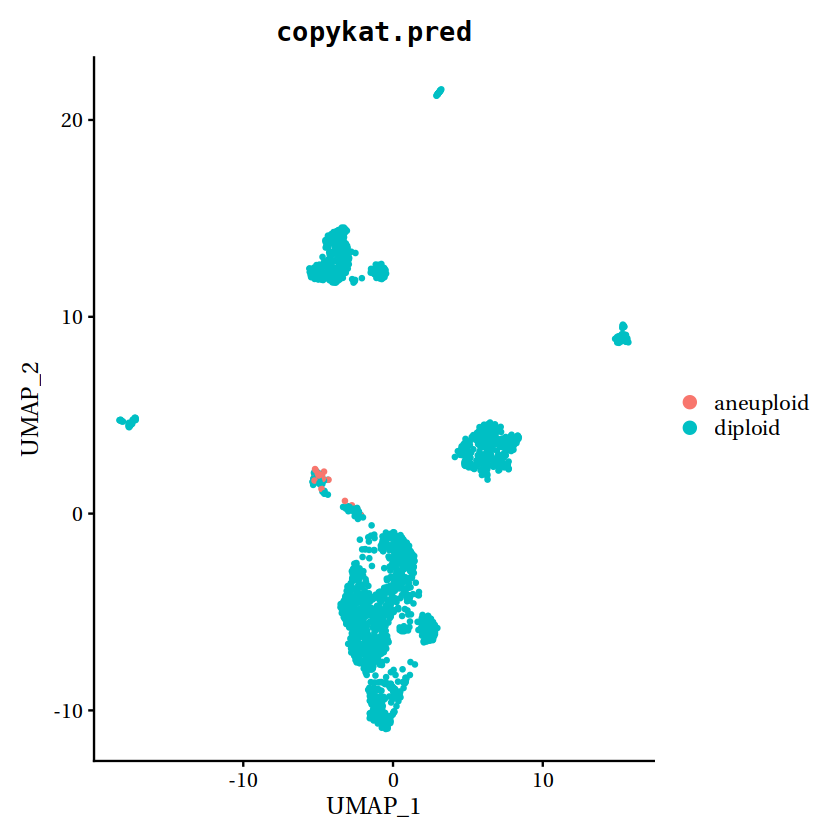

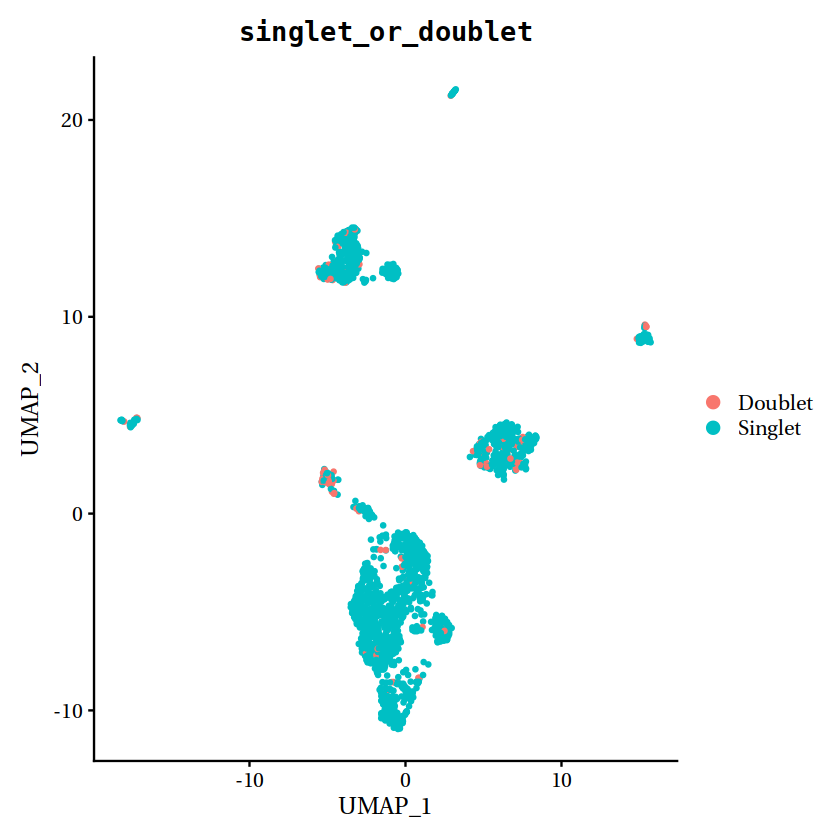

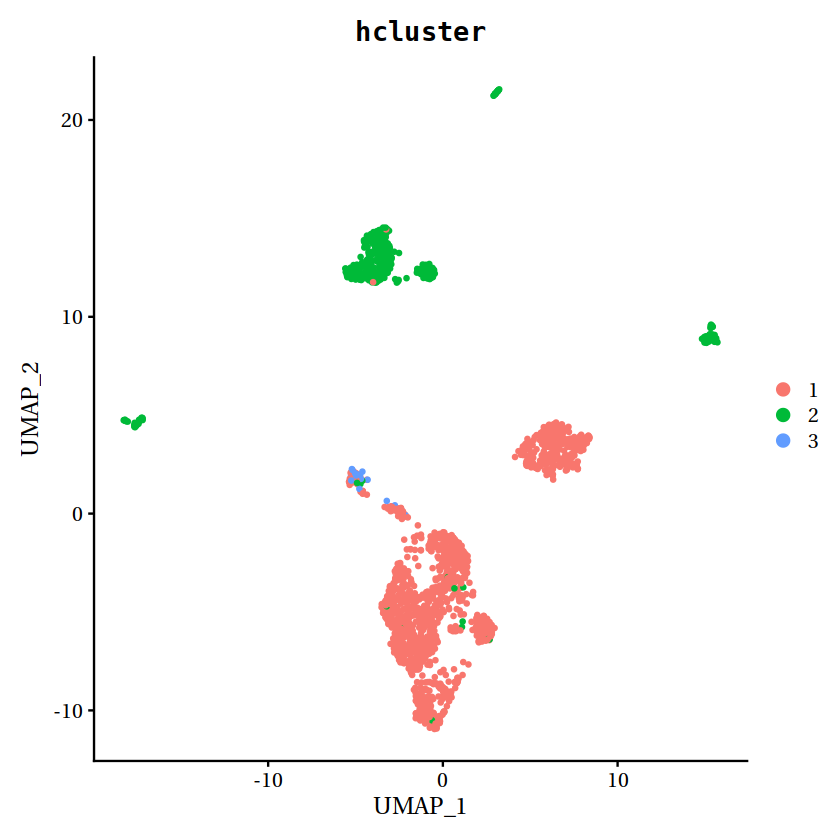

In [84]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")
DimPlot(sub, group.by="hcluster")

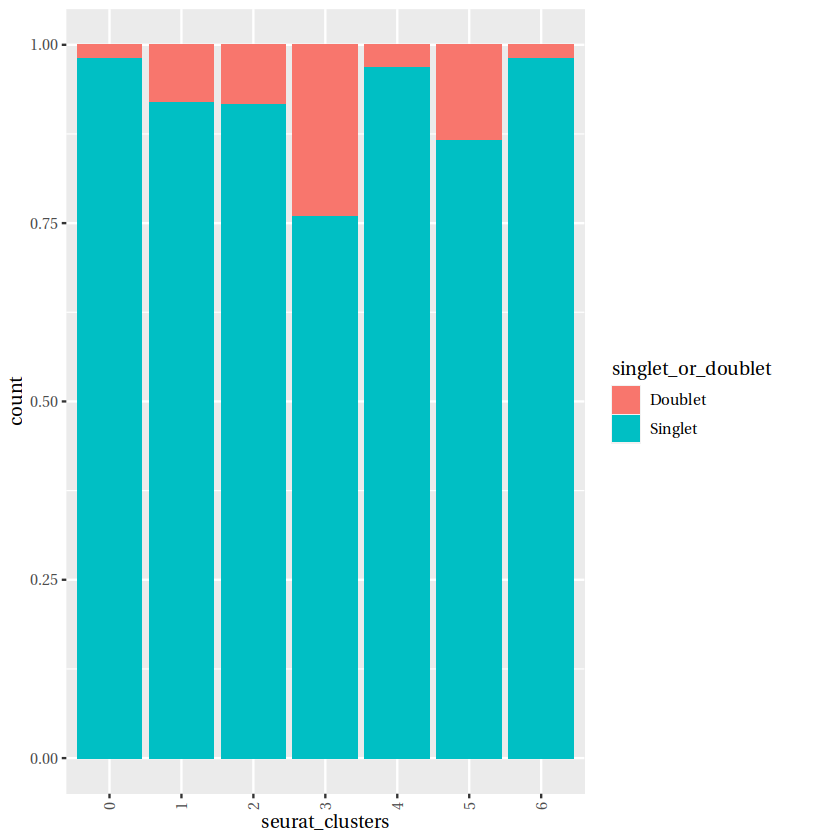

In [85]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

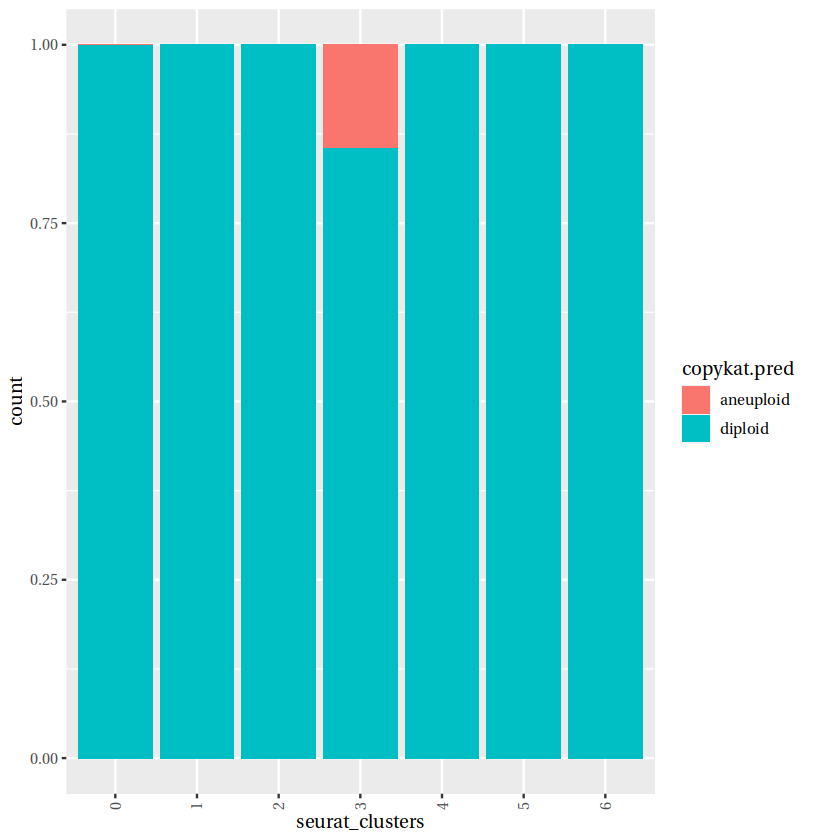

In [86]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

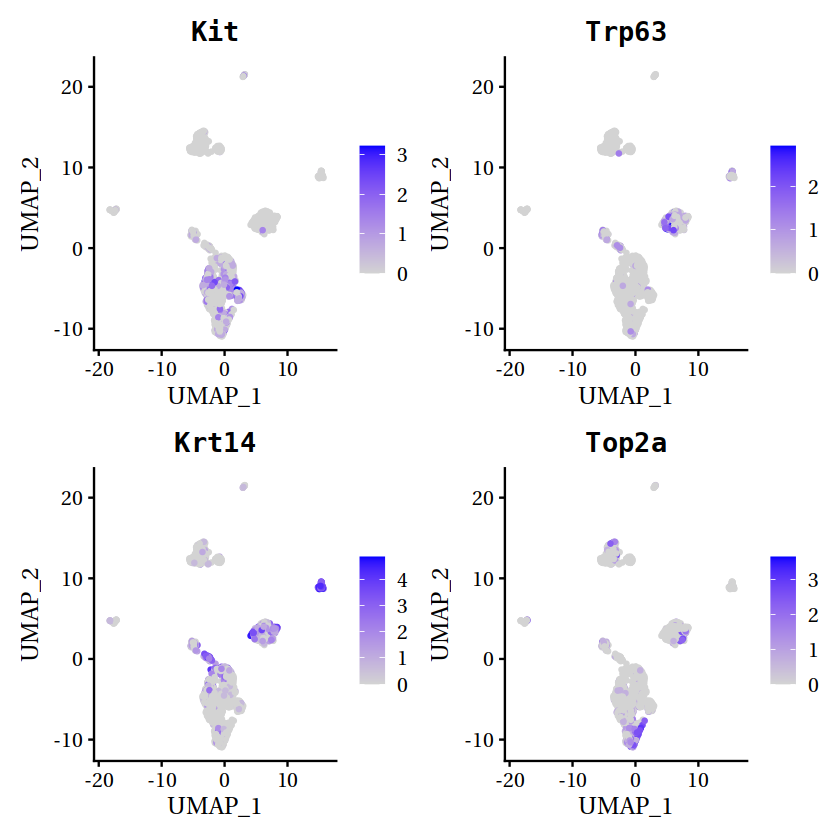

In [87]:
FeaturePlot(sub, c("Kit","Trp63","Krt14","Top2a"))

## clean up (remove tails)

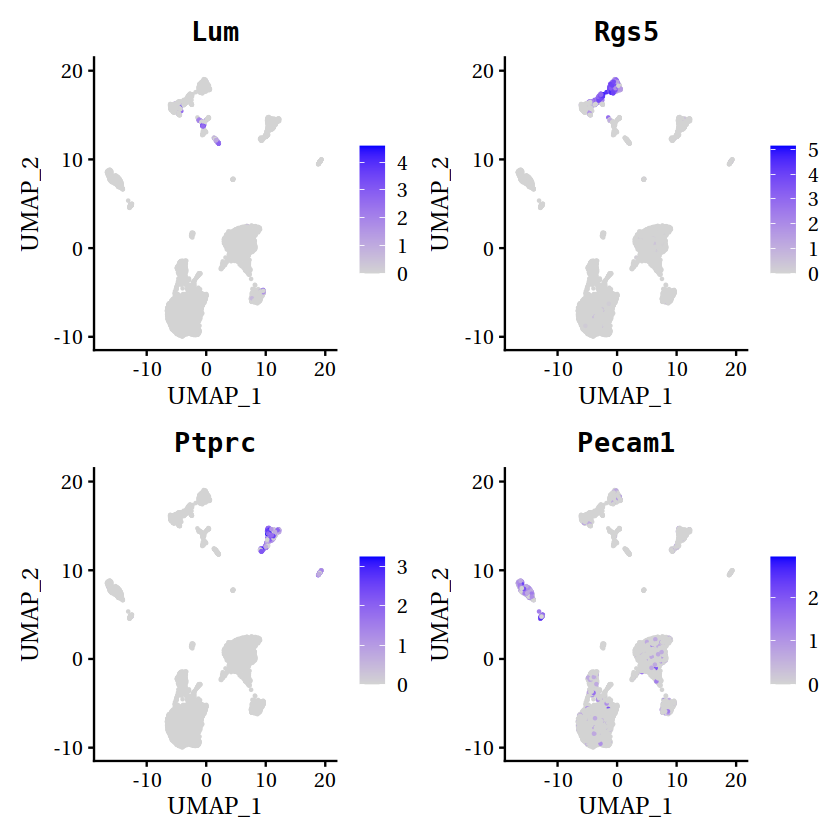

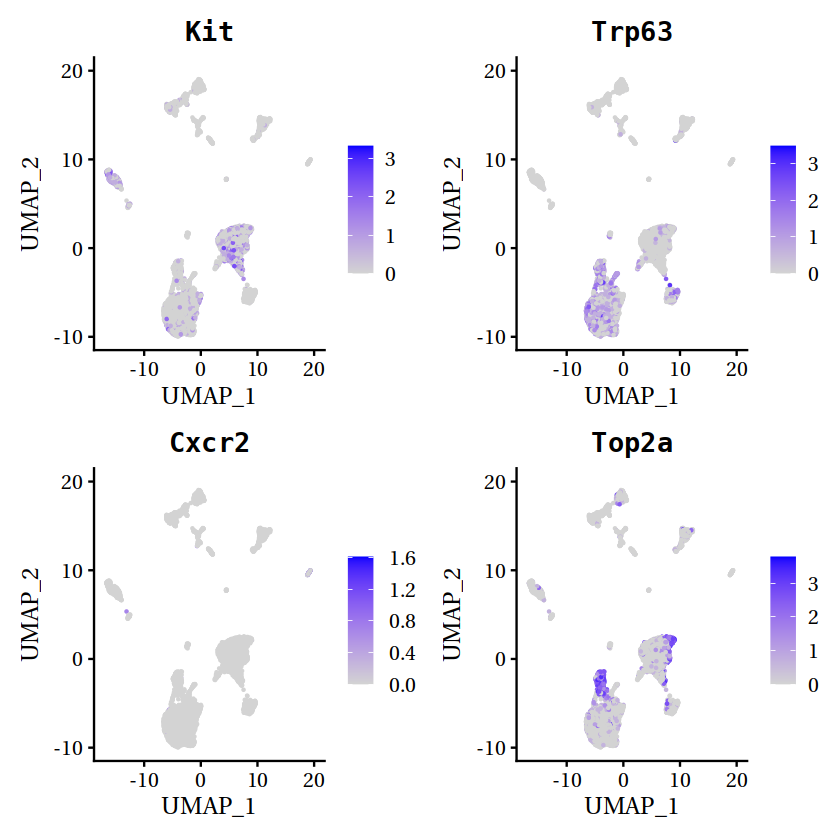

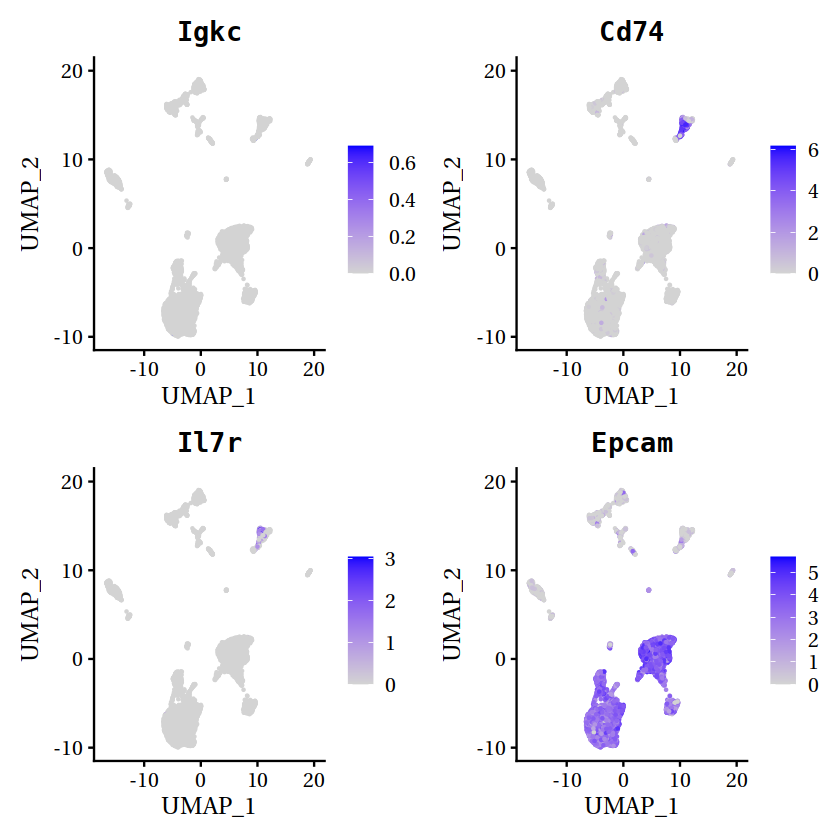

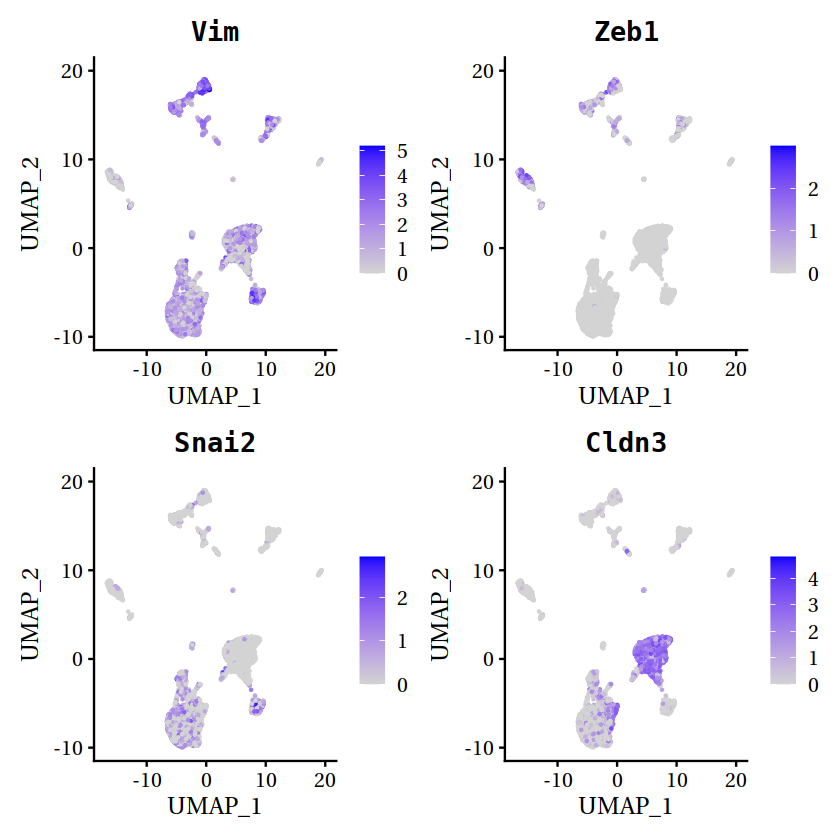

In [46]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

### add important metadata

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

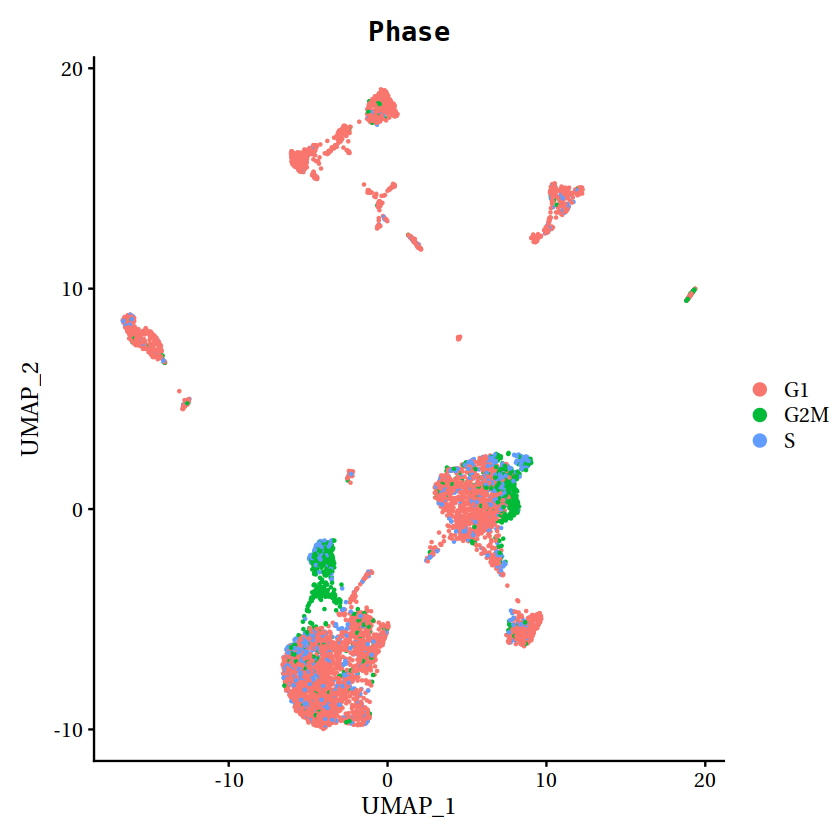

In [47]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

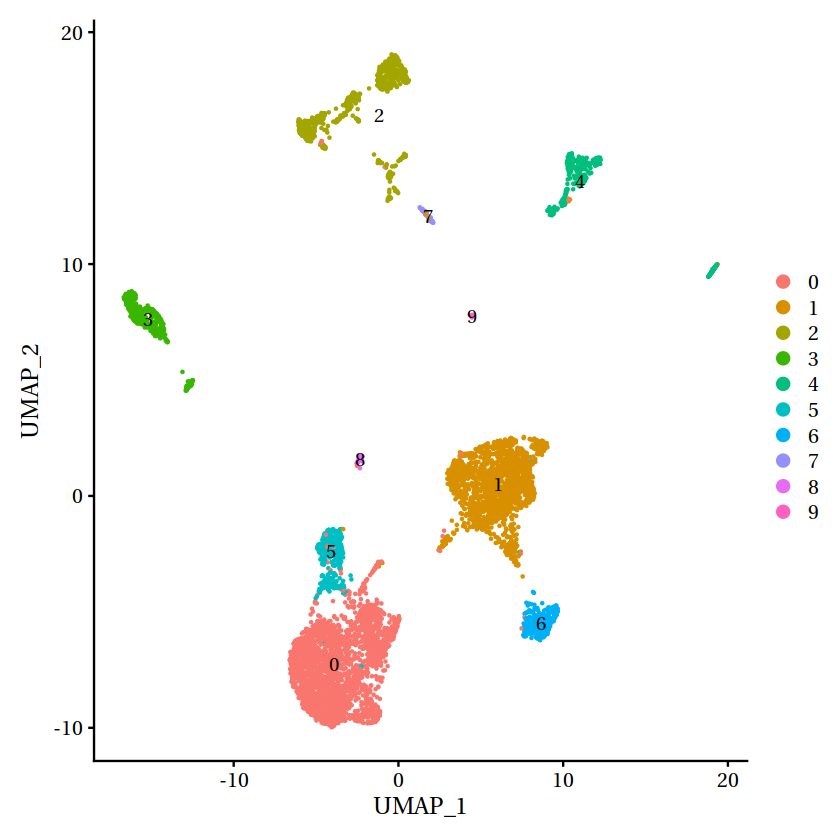

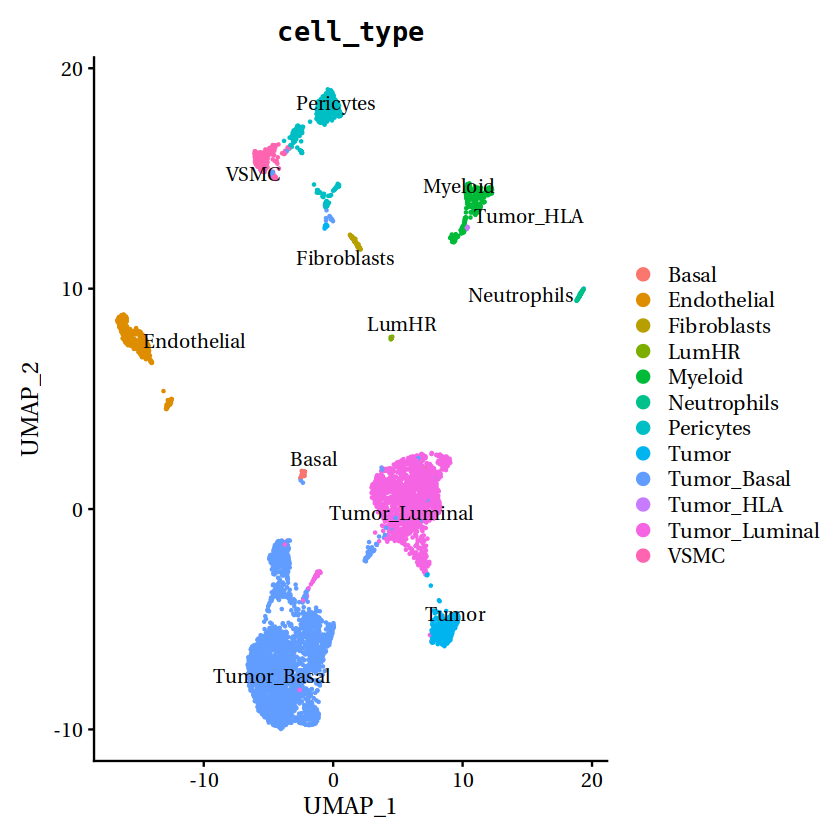

In [48]:
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)

In [51]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Tumor", 
                            `1` = "Tumor", 
                            `2` = "Pericytes", 
                            `3` = "Endothelial",
                            `4` = "Myeloid",
                            `5` = "Tumor",
                            `6` = "Tumor", 
                            `7` = "Fibroblasts", 
                            `8` = "Basal", 
                            `9` = "LumHR")
obj$cell_type <- obj@active.ident

In [52]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Epithelial", 
                            `2` = "Stromal", 
                            `3` = "Stromal",
                            `4` = "Immune",
                            `5` = "Epithelial",
                            `6` = "Epithelial", 
                            `7` = "Stromal", 
                            `8` = "Epithelial", 
                            `9` = "Epithelial")
obj$cell_type_group <- obj@active.ident

In [54]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "mutant", 
                            `liver_2` = "mutant", 
                            `liver_3` = "mutant",
                            `lung_1` = "mutant",
                            `lung_2` = "mutant",
                            `lung_3` = "mutant", 
                            `tum_ortho_colIV` = "mutant")
obj$genotype <- obj@active.ident

In [64]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "liver_1.7", 
                            `liver_2` = "liver_0.8", 
                            `liver_3` = "liver_1.2",
                            `lung_1` = "lung_0.5",
                            `lung_2` = "lung_0.4",
                            `lung_3` = "lung_2.6", 
                            `tum_ortho_colIV` = "tumor_orthotopic")
obj$condition_metastatic_burden <- obj@active.ident

In [59]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "liver_metastasis", 
                            `liver_2` = "liver_metastasis", 
                            `liver_3` = "liver_metastasis",
                            `lung_1` = "lung_metastasis",
                            `lung_2` = "lung_metastasis",
                            `lung_3` = "lung_metastasis", 
                            `tum_ortho_colIV` = "tumor_orthotopic_15mm")
obj$condition_tumor_size_mm <- obj@active.ident

In [58]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "liver_metastasis", 
                            `liver_2` = "liver_metastasis", 
                            `liver_3` = "liver_metastasis",
                            `lung_1` = "lung_metastasis",
                            `lung_2` = "lung_metastasis",
                            `lung_3` = "lung_metastasis", 
                            `tum_ortho_colIV` = "tumor_orthotopic")
obj$condition <- obj@active.ident

In [60]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "liver", 
                            `liver_2` = "liver", 
                            `liver_3` = "liver",
                            `lung_1` = "lung",
                            `lung_2` = "lung",
                            `lung_3` = "lung", 
                            `tum_ortho_colIV` = "mammary")
obj$organ <- obj@active.ident

In [61]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "transplant", 
                            `liver_2` = "transplant", 
                            `liver_3` = "transplant",
                            `lung_1` = "transplant",
                            `lung_2` = "transplant",
                            `lung_3` = "transplant", 
                            `tum_ortho_colIV` = "transplant")
obj$transplant_status <- obj@active.ident

In [62]:
obj$cellplex <- "4"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [63]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "removed", 
                            `liver_2` = "removed", 
                            `liver_3` = "removed",
                            `lung_1` = "removed",
                            `lung_2` = "removed",
                            `lung_3` = "removed", 
                            `tum_ortho_colIV` = "unknown")
obj$lymph_node_presence <- obj@active.ident

In [65]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `liver_1` = "NSG_1", 
                            `liver_2` = "NSG_5", 
                            `liver_3` = "NSG_6",
                            `lung_1` = "NSG_2",
                            `lung_2` = "NSG_4",
                            `lung_3` = "NSG_5", 
                            `tum_ortho_colIV` = "NSG_7")
obj$mouse <- obj@active.ident

In [66]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [67]:
obj$S.Score <- NULL
obj$G2M.Score <- NULL
obj$SCT_snn_res.0.1 <- NULL

In [68]:
meta <- read.csv("cellplex4.adata.obs.metadata.csv", row.names=1)
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [69]:
saveRDS(obj, "cellplex4_soupX_doubletfinder_cnv_metadata.rds")

In [2]:
obj <- readRDS("cellplex4_soupX_doubletfinder_cnv_metadata.rds")

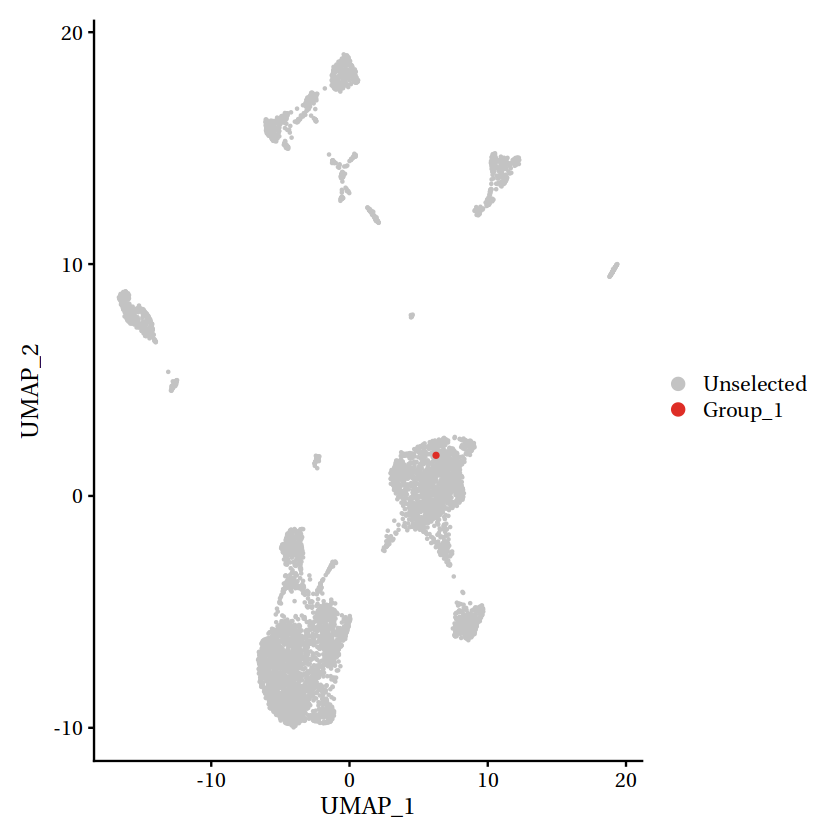

In [6]:
obj$barcode <- colnames(obj)

Idents(obj) <- "barcode"
DimPlot(obj, cells.highlight = WhichCells(obj, ident = c("TTGCTGCTCTTACACT-1")))